# Etape 1 : Data Preprocessing

## A - Fusionnage datasets simple 

In [5]:
import pandas as pd
import glob

# -----------------------------------------------
# 1️⃣ Lecture et combinaison des fichiers
# -----------------------------------------------

path = r"C:/Users/sarah/Downloads/Big_data.csv/Files_used/"
files = glob.glob(path + "*.csv")

if not files:
    raise FileNotFoundError(f"Aucun fichier CSV trouvé dans le dossier : {path}")

data_list = []
print("Lecture et combinaison des fichiers...")

for f in files:
    print(f"📂 Lecture du fichier : {f}")
    try:
        # On essaie d'abord utf-8
        df = pd.read_csv(f, encoding='utf-8', low_memory=False)
    except UnicodeDecodeError:
        # On passe à ISO-8859-1 qui est tolérant aux caractères spéciaux
        print(f"⚠️ Problème d'encodage avec {f}, essai avec 'ISO-8859-1'")
        df = pd.read_csv(f, encoding='ISO-8859-1', low_memory=False)
    data_list.append(df)

# Fusionner tous les fichiers en un seul DataFrame
df_full = pd.concat(data_list, ignore_index=True)
print("✅ Fusion terminée.")
print("Taille totale du dataset :", df_full.shape)

# Vérifier les valeurs uniques de la colonne Label
if " Label" in df_full.columns:
    print("\nExemples de labels présents :")
    print(df_full[" Label"].unique()[:10])


Lecture et combinaison des fichiers...
📂 Lecture du fichier : C:/Users/sarah/Downloads/Big_data.csv/Files_used\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
📂 Lecture du fichier : C:/Users/sarah/Downloads/Big_data.csv/Files_used\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
📂 Lecture du fichier : C:/Users/sarah/Downloads/Big_data.csv/Files_used\Monday-WorkingHours.pcap_ISCX.csv
📂 Lecture du fichier : C:/Users/sarah/Downloads/Big_data.csv/Files_used\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
📂 Lecture du fichier : C:/Users/sarah/Downloads/Big_data.csv/Files_used\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
⚠️ Problème d'encodage avec C:/Users/sarah/Downloads/Big_data.csv/Files_used\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv, essai avec 'ISO-8859-1'
✅ Fusion terminée.
Taille totale du dataset : (1789700, 85)

Exemples de labels présents :
['BENIGN' 'DDoS' 'PortScan' 'Infiltration' 'Web Attack \x96 Brute Force'
 'Web Attack \x96 XSS' 'Web A

## B - Nettoyage des labels

In [6]:
if " Label" in df_full.columns:
    # Remplacer les caractères spéciaux par un tiret normal et supprimer les espaces
    df_full[" Label"] = df_full[" Label"].str.replace(r"[\x96–—]", "-", regex=True).str.strip()
    
    # Vérifier le résultat
    print("\nExemples de labels nettoyés :")
    print(df_full[" Label"].unique()[:10])


Exemples de labels nettoyés :
['BENIGN' 'DDoS' 'PortScan' 'Infiltration' 'Web Attack - Brute Force'
 'Web Attack - XSS' 'Web Attack - Sql Injection' nan]


## C - Échantillonnage stratifié

* Chaque type d’attaque apparaisse dans les mêmes proportions dans l’ensemble d’entraînement et de test.

+ Création d’une colonne binaire (AttackFlag)


In [8]:
from sklearn.model_selection import train_test_split  

# ================================================
# Échantillonnage stratifié du dataset CICIDS2017
# ================================================

# -----------------------------------------------
# 2️⃣ Nettoyage et création d'une colonne binaire
# -----------------------------------------------

# Supprimer les lignes sans label (au cas où)
df_full = df_full.dropna(subset=[" Label"])

# Créer une variable binaire : 0 = BENIGN, 1 = ATTACK
df_full["AttackFlag"] = df_full[" Label"].apply(lambda x: 0 if x == "BENIGN" else 1)


print("\nRépartition initiale des classes :")
print(df_full["AttackFlag"].value_counts())

# -----------------------------------------------
# 3️⃣ Séparation X (features) et y (label)
# -----------------------------------------------
X = df_full.drop(columns=["AttackFlag"])
y = df_full["AttackFlag"]

# -----------------------------------------------
# 4️⃣ Échantillonnage stratifié
# -----------------------------------------------

# On garde par exemple 20 % des données (modifiable)
# test_size = 0.8 => on garde 20 %
X_sample, _, y_sample, _ = train_test_split(
    X, y,
    test_size=0.9,
    stratify=y,
    random_state=42
)

# Fusionner les features et le label
sampled_df = pd.concat([X_sample, y_sample], axis=1)

print("\nRépartition après échantillonnage stratifié :")
print(sampled_df["AttackFlag"].value_counts())

print("\nTaille de l’échantillon :", sampled_df.shape)

# -----------------------------------------------
# 5️⃣ Sauvegarde du dataset échantillonné
# -----------------------------------------------
output_path = r"C:/Users/sarah/Downloads/Big_data.csv/Files_used/BigData_sample.csv"
sampled_df.to_csv(output_path, index=False)

print(f"\n✅ Fichier échantillonné enregistré : {output_path}")



Répartition initiale des classes :
AttackFlag
0    1211925
1     289173
Name: count, dtype: int64

Répartition après échantillonnage stratifié :
AttackFlag
0    121192
1     28917
Name: count, dtype: int64

Taille de l’échantillon : (150109, 86)

✅ Fichier échantillonné enregistré : C:/Users/sarah/Downloads/Big_data.csv/Files_used/BigData_sample.csv


In [9]:
from tabulate import tabulate

# Affichage sous forme de tableau lisible
print("📌 Aperçu du fichier échantillonné :")
print(tabulate(sampled_df.head(), headers='keys', tablefmt='fancy_grid'))


📌 Aperçu du fichier échantillonné :
╒═════════╤═════════════════════════════════════════╤═══════════════╤════════════════╤═══════════════════╤═════════════════════╤═════════════╤════════════════╤══════════════════╤══════════════════════╤═══════════════════════════╤═══════════════════════════════╤════════════════════════════════╤══════════════════════════╤══════════════════════════╤═══════════════════════════╤══════════════════════════╤═════════════════════════╤══════════════════════════╤═══════════════════════════╤══════════════════════════╤════════════════╤═══════════════════╤══════════════════╤══════════════════╤═════════════════╤═════════════════╤═════════════════╤═════════════════╤═════════════════╤════════════════╤════════════════╤═════════════════╤══════════════════╤══════════════════╤════════════════╤════════════════╤═════════════════╤══════════════════╤══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤═════════════════╤══════════════════╤══════

In [10]:
sampled_df.columns.to_list()

['Flow ID',
 ' Source IP',
 ' Source Port',
 ' Destination IP',
 ' Destination Port',
 ' Protocol',
 ' Timestamp',
 ' Flow Duration',
 ' Total Fwd Packets',
 ' Total Backward Packets',
 'Total Length of Fwd Packets',
 ' Total Length of Bwd Packets',
 ' Fwd Packet Length Max',
 ' Fwd Packet Length Min',
 ' Fwd Packet Length Mean',
 ' Fwd Packet Length Std',
 'Bwd Packet Length Max',
 ' Bwd Packet Length Min',
 ' Bwd Packet Length Mean',
 ' Bwd Packet Length Std',
 'Flow Bytes/s',
 ' Flow Packets/s',
 ' Flow IAT Mean',
 ' Flow IAT Std',
 ' Flow IAT Max',
 ' Flow IAT Min',
 'Fwd IAT Total',
 ' Fwd IAT Mean',
 ' Fwd IAT Std',
 ' Fwd IAT Max',
 ' Fwd IAT Min',
 'Bwd IAT Total',
 ' Bwd IAT Mean',
 ' Bwd IAT Std',
 ' Bwd IAT Max',
 ' Bwd IAT Min',
 'Fwd PSH Flags',
 ' Bwd PSH Flags',
 ' Fwd URG Flags',
 ' Bwd URG Flags',
 ' Fwd Header Length',
 ' Bwd Header Length',
 'Fwd Packets/s',
 ' Bwd Packets/s',
 ' Min Packet Length',
 ' Max Packet Length',
 ' Packet Length Mean',
 ' Packet Length Std'

In [11]:
sampled_df[' Label'].unique()

array(['BENIGN', 'PortScan', 'DDoS', 'Web Attack - Sql Injection',
       'Web Attack - XSS', 'Web Attack - Brute Force', 'Infiltration'],
      dtype=object)

In [1]:
import pandas as pd

sampled_df = pd.read_csv("C:/Users/sarah/Downloads/Big_data.csv/Files_used/BigData_sample.csv")

In [2]:
sampled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150109 entries, 0 to 150108
Data columns (total 86 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flow ID                       150109 non-null  object 
 1    Source IP                    150109 non-null  object 
 2    Source Port                  150109 non-null  float64
 3    Destination IP               150109 non-null  object 
 4    Destination Port             150109 non-null  float64
 5    Protocol                     150109 non-null  float64
 6    Timestamp                    150109 non-null  object 
 7    Flow Duration                150109 non-null  float64
 8    Total Fwd Packets            150109 non-null  float64
 9    Total Backward Packets       150109 non-null  float64
 10  Total Length of Fwd Packets   150109 non-null  float64
 11   Total Length of Bwd Packets  150109 non-null  float64
 12   Fwd Packet Length Max        150109 non-nul

## D - Gestion des colonnes et types de données

In [3]:
# Supprimer les espaces avant/après dans tous les noms de colonnes
sampled_df.columns = sampled_df.columns.str.strip()
print(sampled_df.columns.tolist())

['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH 

In [4]:
# Colonnes qui doivent rester en object
object_cols = ["Flow ID", "Source IP", "Destination IP", "Timestamp", "Label"]

# Colonnes qui devraient être des entiers
int_cols = ["Source Port", "Destination Port", "Protocol", "AttackFlag"]

# Conversion des colonnes int
for col in int_cols:
    sampled_df[col] = sampled_df[col].astype(int)

# Conversion des colonnes object
for col in object_cols:
    sampled_df[col] = sampled_df[col].astype(str)

print(sampled_df.dtypes)


Flow ID              object
Source IP            object
Source Port           int32
Destination IP       object
Destination Port      int32
                     ...   
Idle Std            float64
Idle Max            float64
Idle Min            float64
Label                object
AttackFlag            int32
Length: 86, dtype: object


## E - Vérifier les doublons

In [5]:
print("Taille du dataset avant suppression des doublons :", sampled_df.shape)
num_duplicates = sampled_df.duplicated().sum()
print(f"Nombre de doublons : {num_duplicates}")

Taille du dataset avant suppression des doublons : (150109, 86)
Nombre de doublons : 3


In [6]:
sampled_df = sampled_df.drop_duplicates()
print("Taille du dataset après suppression des doublons :", sampled_df.shape)

Taille du dataset après suppression des doublons : (150106, 86)


## F - Imputation des valeurs infinies 

In [7]:
import numpy as np

# Colonnes numériques uniquement
numeric_cols = sampled_df.select_dtypes(include=['int64', 'float64']).columns

# Vérifier si des colonnes contiennent des infinis
cols_with_inf = []
for col in numeric_cols:
    if np.isinf(sampled_df[col]).any():
        cols_with_inf.append(col)

print("Colonnes contenant des valeurs infinies :")
print(cols_with_inf)


Colonnes contenant des valeurs infinies :
['Flow Bytes/s', 'Flow Packets/s']


In [8]:
for col in cols_with_inf:
    n_inf = np.isinf(sampled_df[col]).sum()
    print(f"{col} contient {n_inf} valeurs infinies")


Flow Bytes/s contient 108 valeurs infinies
Flow Packets/s contient 124 valeurs infinies


In [9]:
import numpy as np

# Colonnes numériques
numeric_cols = sampled_df.select_dtypes(include=['int64', 'float64']).columns

# Colonnes contenant au moins un infini
cols_with_inf = [col for col in numeric_cols if np.isinf(sampled_df[col]).any()]

# Masque pour détecter toutes les lignes avec au moins un infini
mask_inf = sampled_df[cols_with_inf].apply(lambda x: np.isinf(x)).any(axis=1)

# Afficher uniquement les lignes et colonnes concernées
df_inf_rows = sampled_df.loc[mask_inf, cols_with_inf]

print("Lignes avec au moins une valeur infinie (colonnes filtrées) :")
print(df_inf_rows.head())



Lignes avec au moins une valeur infinie (colonnes filtrées) :
      Flow Bytes/s  Flow Packets/s
86             inf             inf
2429           inf             inf
3043           inf             inf
5159           inf             inf
5214           inf             inf


In [10]:
import numpy as np

# Colonnes à vérifier
cols_to_check = ["Flow Bytes/s", "Flow Packets/s"]

# Masque pour détecter les lignes où les deux colonnes contiennent inf
mask_inf_both = np.isinf(sampled_df[cols_to_check[0]]) & np.isinf(sampled_df[cols_to_check[1]])

# Sélection des lignes
df_inf_both = sampled_df.loc[mask_inf_both, cols_to_check + ["Label"]]  # ajouter Label pour référence

print(f"Lignes où les deux colonnes ont 'inf' : {len(df_inf_both)} lignes")
print(df_inf_both.head())


Lignes où les deux colonnes ont 'inf' : 108 lignes
      Flow Bytes/s  Flow Packets/s   Label
86             inf             inf  BENIGN
2429           inf             inf  BENIGN
3043           inf             inf  BENIGN
5159           inf             inf  BENIGN
5214           inf             inf  BENIGN


Probléme : Le champ Flow Bytes/s et Flow Packets/s contiennent parfois des valeurs Inf lorsque le débit est trop élevé ou mal enregistré.

=> On doit donc imputer ces valeurs par une valeur réaliste.

Solution : 
- Imputer les valeurs Inf pour les flux BENIGN avec la valeur maximale des BENIGN de tous les fichiers confondus.(autrement dit, un max global BENIGN).

- Et pour les flux d’attaque (DDoS, WebAttack…) : On va imputer avec le max local correspondant à chaque type d’attaque, car leurs distributions peuvent être très différentes.

In [11]:
import numpy as np
import pandas as pd

# --- Copier le DataFrame existant pour créer une version imputée ---
sampled_df = sampled_df.copy()

# --- Colonne label (gère "Label" ou " Label") ---
if "Label" in sampled_df.columns:
    label_col = "Label"
elif " Label" in sampled_df.columns:
    label_col = " Label"
else:
    raise KeyError("Aucune colonne 'Label' ou ' Label' trouvée dans le DataFrame.")

# --- Colonnes à corriger ---
cols_to_fix = ["Flow Bytes/s", "Flow Packets/s"]
round_decimals = 2

# Vérification : colonnes existantes
cols_to_fix = [c for c in cols_to_fix if c in sampled_df.columns]
if not cols_to_fix:
    raise KeyError("Aucune des colonnes 'Flow Bytes/s' ou 'Flow Packets/s' n'existe dans le DataFrame.")

# Rapport initial : nombre d'inf par colonne
print("🔍 AVANT IMPUTATION :")
for col in cols_to_fix:
    print(f" - {col}: +inf = {np.isposinf(sampled_df[col]).sum()}, -inf = {np.isneginf(sampled_df[col]).sum()}")

print("\n" + "="*60)
print("🎯 CALCUL DES VALEURS DE REMPLACEMENT")
print("="*60)

# --- Calcul des remplacements ---
# 1) Remplacement GLOBAL pour BENIGN (max sur tous les BENIGN)
print("\n📊 MAX GLOBAL POUR BENIGN (tous fichiers confondus):")
global_repl = {}
benign_mask = sampled_df[label_col] == "BENIGN"

for col in cols_to_fix:
    finite_benign = sampled_df.loc[benign_mask & np.isfinite(sampled_df[col]), col]
    global_max = round(float(finite_benign.max()), round_decimals) if not finite_benign.empty else 0.0
    global_min = round(float(finite_benign.min()), round_decimals) if not finite_benign.empty else 0.0
    global_repl[col] = {"max": global_max, "min": global_min}
    print(f"   {col}: MAX = {global_max:,}")

# 2) Remplacement PAR LABEL pour chaque attaque
print("\n📈 MAX PAR TYPE D'ATTAQUE (local à chaque type):")
labels = sampled_df[label_col].dropna().unique()
label_repl = {}

for lab in labels:
    if lab == "BENIGN":
        continue  # On a déjà traité BENIGN
    
    print(f"\n   🎯 {lab}:")
    label_repl[lab] = {}
    
    for col in cols_to_fix:
        finite_vals = sampled_df.loc[(sampled_df[label_col] == lab) & np.isfinite(sampled_df[col]), col]
        max_val = round(float(finite_vals.max()), round_decimals) if not finite_vals.empty else global_repl[col]["max"]
        min_val = round(float(finite_vals.min()), round_decimals) if not finite_vals.empty else global_repl[col]["min"]
        label_repl[lab][col] = {"max": max_val, "min": min_val}
        print(f"      {col}: MAX = {max_val:,}")

print("\n" + "="*60)
print("🔄 APPLICATION DES REMPLACEMENTS")
print("="*60)

# --- Appliquer les remplacements avec affichage détaillé ---
total_replacements = 0

for col in cols_to_fix:
    print(f"\n📝 Traitement de la colonne: {col}")
    col_replacements = 0
    
    for lab in labels:
        mask_pos_inf = (sampled_df[label_col] == lab) & np.isposinf(sampled_df[col])
        count_pos_inf = mask_pos_inf.sum()
        
        if count_pos_inf > 0:
            if lab == "BENIGN":
                repl_value = global_repl[col]["max"]
                repl_type = "GLOBAL BENIGN"
            else:
                repl_value = label_repl[lab][col]["max"]
                repl_type = f"LOCAL {lab}"
            
            # Appliquer le remplacement
            sampled_df.loc[mask_pos_inf, col] = repl_value
            col_replacements += count_pos_inf
            
            print(f"   ✅ {lab}: {count_pos_inf} valeurs +inf → {repl_value:,} ({repl_type})")
        else:
            # Afficher même s'il n'y a pas de remplacement pour voir tous les types
            if lab != "BENIGN":
                if lab in label_repl:
                    repl_value = label_repl[lab][col]["max"]
                    print(f"   ➖ {lab}: 0 valeurs +inf (MAX disponible = {repl_value:,})")
    
    total_replacements += col_replacements
    print(f"   📊 Total remplacé dans {col}: {col_replacements} valeurs")

# Arrondir les colonnes
sampled_df[cols_to_fix] = sampled_df[cols_to_fix].round(round_decimals)

print("\n" + "="*60)
print("📊 RÉSUMÉ FINAL")
print("="*60)

print(f"\n🎯 TOTAL DES VALEURS REMPLACÉES: {total_replacements}")

print("\n🔍 APRÈS IMPUTATION :")
for col in cols_to_fix:
    remaining_inf = np.isposinf(sampled_df[col]).sum() + np.isneginf(sampled_df[col]).sum()
    print(f" - {col}: valeurs inf restantes = {remaining_inf}")

print(f"\n✅ IMPUTATION TERMINÉE AVEC SUCCÈS!")

🔍 AVANT IMPUTATION :
 - Flow Bytes/s: +inf = 108, -inf = 0
 - Flow Packets/s: +inf = 124, -inf = 0

🎯 CALCUL DES VALEURS DE REMPLACEMENT

📊 MAX GLOBAL POUR BENIGN (tous fichiers confondus):
   Flow Bytes/s: MAX = 2,071,000,000.0
   Flow Packets/s: MAX = 3,000,000.0

📈 MAX PAR TYPE D'ATTAQUE (local à chaque type):

   🎯 PortScan:
      Flow Bytes/s: MAX = 8,000,000.0
      Flow Packets/s: MAX = 2,000,000.0

   🎯 DDoS:
      Flow Bytes/s: MAX = 53,100,000.0
      Flow Packets/s: MAX = 114,285.71

   🎯 Web Attack - Sql Injection:
      Flow Bytes/s: MAX = 933.64
      Flow Packets/s: MAX = 47,619.05

   🎯 Web Attack - XSS:
      Flow Bytes/s: MAX = 3,848.51
      Flow Packets/s: MAX = 25,974.03

   🎯 Web Attack - Brute Force:
      Flow Bytes/s: MAX = 3,490.34
      Flow Packets/s: MAX = 95,238.1

   🎯 Infiltration:
      Flow Bytes/s: MAX = 2,735.52
      Flow Packets/s: MAX = 19.38

🔄 APPLICATION DES REMPLACEMENTS

📝 Traitement de la colonne: Flow Bytes/s
   ✅ BENIGN: 97 valeurs +inf → 

## F - Vérifier les valeurs manquantes 

In [12]:
# Permettre l'affichage de toutes les colonnes
import pandas as pd
pd.set_option('display.max_rows', None)  # affiche toutes les lignes
pd.set_option('display.max_columns', None)  # affiche toutes les colonnes
pd.set_option('display.width', 1000)  # largeur maximale pour éviter le wrapping

# Affichage des valeurs manquantes
print(sampled_df.isnull().sum())

Flow ID                         0
Source IP                       0
Source Port                     0
Destination IP                  0
Destination Port                0
Protocol                        0
Timestamp                       0
Flow Duration                   0
Total Fwd Packets               0
Total Backward Packets          0
Total Length of Fwd Packets     0
Total Length of Bwd Packets     0
Fwd Packet Length Max           0
Fwd Packet Length Min           0
Fwd Packet Length Mean          0
Fwd Packet Length Std           0
Bwd Packet Length Max           0
Bwd Packet Length Min           0
Bwd Packet Length Mean          0
Bwd Packet Length Std           0
Flow Bytes/s                   16
Flow Packets/s                  0
Flow IAT Mean                   0
Flow IAT Std                    0
Flow IAT Max                    0
Flow IAT Min                    0
Fwd IAT Total                   0
Fwd IAT Mean                    0
Fwd IAT Std                     0
Fwd IAT Max   

In [13]:
import pandas as pd
from tabulate import tabulate  

def localiser_nan_tableau(df):
    """Affiche toutes les lignes contenant des NaN sous forme de tableau lisible."""
    print("🔍 LOCALISATION DES VALEURS NaN")
    print("=" * 70)
    
    # 1️⃣ Colonnes contenant des NaN
    nan_counts = df.isna().sum()
    cols_nan = nan_counts[nan_counts > 0]
    
    if cols_nan.empty:
        print("✅ Aucun NaN détecté dans le DataFrame.")
        return None, None
    
    # 2️⃣ Résumé par colonne
    print("\n📊 Colonnes avec NaN :")
    print(tabulate(
        cols_nan.reset_index().rename(columns={"index": "Colonne", 0: "Nb_NaN"}),
        headers=["Colonne", "Nb_NaN"],
        tablefmt="grid"
    ))
    
    # 3️⃣ Extraire toutes les lignes contenant au moins un NaN
    rows_nan = df[df.isna().any(axis=1)].copy()
    print(f"\n📍 Total : {len(rows_nan)} lignes contiennent au moins un NaN.\n")
    
    # 4️⃣ Ajouter l’index d’origine pour repérage
    rows_nan.insert(0, "Index_Original", rows_nan.index)
    
    # 5️⃣ Remplacer les NaN par une indication visuelle
    df_display = rows_nan.fillna("❌ NaN")
    
    # 6️⃣ Afficher le tableau complet
    print(tabulate(df_display, headers="keys", tablefmt="grid", showindex=False))
    
    # 7️⃣ Résumé final
    print(f"\n🎯 Résumé : {len(cols_nan)} colonnes concernées, {len(rows_nan)} lignes affectées.")
    
    return cols_nan, rows_nan


# Exemple d'utilisation :
colonnes_nan, lignes_nan = localiser_nan_tableau(sampled_df)


🔍 LOCALISATION DES VALEURS NaN

📊 Colonnes avec NaN :
+----+--------------+----------+
|    | Colonne      |   Nb_NaN |
+====+==============+==========+
|  0 | Flow Bytes/s |       16 |
+----+--------------+----------+

📍 Total : 16 lignes contiennent au moins un NaN.

+------------------+-------------------------------------------+----------------+---------------+------------------+--------------------+------------+---------------------+-----------------+---------------------+--------------------------+-------------------------------+-------------------------------+-------------------------+-------------------------+--------------------------+-------------------------+-------------------------+-------------------------+--------------------------+-------------------------+----------------+------------------+-----------------+----------------+----------------+----------------+-----------------+----------------+---------------+---------------+---------------+-----------------+-----------

In [14]:
# Supprimer les lignes avec FlowBytes NaN puisque "Label" == "BENIGN": 16 lignes n'appartiennent pas à une classe rare.
sampled_df = sampled_df.dropna(subset=['Flow Bytes/s']).copy()

print(f"Taille du dataset après suppression : {sampled_df.shape}")

Taille du dataset après suppression : (150090, 86)


 VERIFICATION 

In [15]:
def verification_express(sampled_df):
    """Vérification ultra-rapide en 3 points"""
    
    print("⚡ VÉRIFICATION EXPRESS")
    print("=" * 40)
    
    # 1. Total valeurs infinies dans tout le dataset
    numeric_cols = sampled_df.select_dtypes(include=[np.number]).columns
    total_inf = np.isinf(sampled_df[numeric_cols]).sum().sum()
    
    print(f"1. Total valeurs infinies: {total_inf}")
    
    # 2. Vérification spécifique des colonnes problématiques
    colonnes_critiques = ['Flow Bytes/s', 'Flow Packets/s']
    inf_critiques = 0
    
    for col in colonnes_critiques:
        if col in sampled_df.columns:
            inf_count = np.isinf(sampled_df[col]).sum()
            inf_critiques += inf_count
            print(f"2. {col}: {inf_count} inf")
    
    # 3. Vérification des NaN
    total_nan = sampled_df.isnull().sum().sum()
    print(f"3. Total valeurs NaN: {total_nan}")
    
    # CONCLUSION
    print(f"\n📊 RÉSULTAT:")
    if total_inf == 0 and inf_critiques == 0 and total_nan == 0:
        print("✅ PARFAIT! Dataset complètement nettoyé")
        return True
    else:
        print("❌ Problèmes détectés")
        return False

# Vérification express
statut_ok = verification_express(sampled_df)

⚡ VÉRIFICATION EXPRESS
1. Total valeurs infinies: 0
2. Flow Bytes/s: 0 inf
2. Flow Packets/s: 0 inf
3. Total valeurs NaN: 0

📊 RÉSULTAT:
✅ PARFAIT! Dataset complètement nettoyé


## G - Standardisation des valeurs numériques  

In [16]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from tabulate import tabulate

def detecter_et_standardiser_avec_tableau(df):
    """Détecte automatiquement les colonnes à standardiser et affiche un tableau comparatif"""
    
    print("🎯 DÉTECTION ET STANDARDISATION AVEC TABLEAU COMPARATIF")
    print("=" * 80)
    
    # Créer une copie du DataFrame
    df_standardise = df.copy()
    
    # Liste pour stocker les colonnes à standardiser
    colonnes_a_standardiser = []
    stats_avant = {}  # Stocker les stats avant standardisation
    
    print("🔍 ANALYSE DES COLONNES NUMÉRIQUES:")
    print("-" * 50)
    
    # Analyser chaque colonne numérique
    for col in df.select_dtypes(include=[np.number]).columns:
        # Exclure les colonnes binaires (0/1)
        unique_vals = df[col].nunique()
        is_binary = unique_vals <= 2 and set(df[col].dropna().unique()).issubset({0, 1})
        
        # Exclure les flags réseau
        is_flag = any(flag in col.lower() for flag in ['flag', 'fin', 'syn', 'rst', 'psh', 'ack', 'urg', 'cwe', 'ece'])
        
        # Exclure les colonnes à faible cardinalité (moins de 20 valeurs uniques)
        is_low_cardinality = unique_vals <= 20
        
        # Statistiques pour décision
        if not is_binary and not is_flag and not is_low_cardinality:
            mean_val = df[col].mean()
            std_val = df[col].std()
            range_val = df[col].max() - df[col].min()
            cv = std_val / (abs(mean_val) + 1e-8)  # Coefficient de variation
            
            # Critères pour standardisation
            needs_scaling = (
                std_val > 100 or           # Écart-type élevé
                range_val > 1000 or        # Plage de valeurs large
                cv > 0.1 or               # Variation relative importante
                abs(mean_val) > 100       # Moyenne éloignée de 0
            )
            
            if needs_scaling:
                colonnes_a_standardiser.append(col)
                stats_avant[col] = {
                    'moyenne': mean_val,
                    'ecart_type': std_val,
                    'min': df[col].min(),
                    'max': df[col].max()
                }
    
    if not colonnes_a_standardiser:
        print("❌ AUCUNE COLONNE À STANDARDISER DÉTECTÉE")
        return df, None, []
    
    # Afficher le tableau AVANT standardisation
    print(f"\n📈 TABLEAU AVANT STANDARDISATION:")
    print("-" * 80)
    
    tableau_avant = []
    for col in colonnes_a_standardiser:
        stats = stats_avant[col]
        tableau_avant.append([
            col,
            f"{stats['moyenne']:,.2f}",
            f"{stats['ecart_type']:,.2f}",
            f"{stats['min']:,.2f}",
            f"{stats['max']:,.2f}"
        ])
    
    en_tetes = ['Colonne', 'Moyenne', 'Écart-type', 'Minimum', 'Maximum']
    print(tabulate(tableau_avant, headers=en_tetes, tablefmt='grid', stralign='right'))
    
    # Appliquer la standardisation
    print(f"\n🔄 APPLICATION DE LA STANDARDISATION...")
    scaler = StandardScaler()
    df_standardise[colonnes_a_standardiser] = scaler.fit_transform(df_standardise[colonnes_a_standardiser])
    
    # Afficher le tableau APRÈS standardisation
    print(f"\n📊 TABLEAU APRÈS STANDARDISATION:")
    print("-" * 80)
    
    tableau_apres = []
    for col in colonnes_a_standardiser:
        stats = {
            'moyenne': df_standardise[col].mean(),
            'ecart_type': df_standardise[col].std(),
            'min': df_standardise[col].min(),
            'max': df_standardise[col].max()
        }
        tableau_apres.append([
            col,
            f"{stats['moyenne']:.6f}",
            f"{stats['ecart_type']:.6f}",
            f"{stats['min']:.6f}",
            f"{stats['max']:.6f}"
        ])
    
    print(tabulate(tableau_apres, headers=en_tetes, tablefmt='grid', stralign='right'))
    
    # Tableau comparatif résumé
    print(f"\n📋 TABLEAU COMPARATIF RÉSUMÉ:")
    print("-" * 100)
    
    tableau_comparatif = []
    for col in colonnes_a_standardiser[:10]:  # Afficher les 10 premières pour éviter le spam
        avant = stats_avant[col]
        apres = {
            'moyenne': df_standardise[col].mean(),
            'ecart_type': df_standardise[col].std()
        }
        
        # Vérification de la qualité de standardisation
        qualite = "✅ BONNE" if abs(apres['moyenne']) < 0.01 and abs(apres['ecart_type'] - 1) < 0.01 else "⚠️  À VÉRIFIER"
        
        tableau_comparatif.append([
            col,
            f"{avant['moyenne']:,.2f}",
            f"{avant['ecart_type']:,.2f}",
            f"{apres['moyenne']:.6f}",
            f"{apres['ecart_type']:.6f}",
            qualite
        ])
    
    en_tetes_comparatif = ['Colonne', 'Moyenne (Avant)', 'Écart-type (Avant)', 'Moyenne (Après)', 'Écart-type (Après)', 'Qualité']
    print(tabulate(tableau_comparatif, headers=en_tetes_comparatif, tablefmt='grid', stralign='right'))
    
    if len(colonnes_a_standardiser) > 10:
        print(f"\n... et {len(colonnes_a_standardiser) - 10} autres colonnes standardisées")
    
    # Résumé final
    print(f"\n✅ STANDARDISATION TERMINÉE!")
    print(f"📊 RÉSUMÉ: {len(colonnes_a_standardiser)} colonnes standardisées avec succès")
    
    return df_standardise, scaler, colonnes_a_standardiser

# Appliquer la détection et standardisation avec tableau comparatif
df_standardise, scaler, colonnes_standardisees = detecter_et_standardiser_avec_tableau(sampled_df)

🎯 DÉTECTION ET STANDARDISATION AVEC TABLEAU COMPARATIF
🔍 ANALYSE DES COLONNES NUMÉRIQUES:
--------------------------------------------------

📈 TABLEAU AVANT STANDARDISATION:
--------------------------------------------------------------------------------
+------------------------+---------------+---------------+-------------------+------------------+
|                Colonne |       Moyenne |    Écart-type |           Minimum |          Maximum |
+========================+===============+===============+===================+==================+
|            Source Port |     40,903.58 |     22,729.44 |              0.00 |        65,535.00 |
+------------------------+---------------+---------------+-------------------+------------------+
|       Destination Port |      9,155.84 |     19,124.51 |              0.00 |        65,531.00 |
+------------------------+---------------+---------------+-------------------+------------------+
|          Flow Duration | 10,189,331.01 | 28,256,205.60 |

In [17]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate

def standardiser_avec_affichage_min_max(df):
    """Standardisation avec affichage des 3 valeurs min et 3 valeurs max pour chaque colonne."""
    
    print("🎯 STANDARDISATION AVEC AFFICHAGE DES EXTREMES")
    print("=" * 100)
    
    colonnes_a_standardiser = []
    for col in df.select_dtypes(include=[np.number]).columns:
        unique_vals = df[col].nunique()
        is_binary = unique_vals <= 2 and set(df[col].dropna().unique()).issubset({0, 1})
        is_flag = any(flag in col.lower() for flag in ['flag', 'fin', 'syn', 'rst', 'psh', 'ack', 'urg', 'cwe', 'ece'])
        is_low_cardinality = unique_vals <= 20
        
        if not is_binary and not is_flag and not is_low_cardinality:
            std_val = df[col].std()
            range_val = df[col].max() - df[col].min()
            if std_val > 100 or range_val > 1000:
                colonnes_a_standardiser.append(col)
    
    if not colonnes_a_standardiser:
        print("❌ AUCUNE COLONNE À STANDARDISER")
        return df, None, []
    
    # Standardisation
    df_std = df.copy()
    scaler = StandardScaler()
    df_std[colonnes_a_standardiser] = scaler.fit_transform(df_std[colonnes_a_standardiser])
    
    print(f"\n📋 COMPARAISON VALEURS AVANT / APRÈS STANDARDISATION (min/max)")
    print("=" * 100)
    
    for col in colonnes_a_standardiser[:3]:  # limiter l'affichage à 3 colonnes max
        print(f"\n📊 COLONNE : {col}")
        print("-" * 80)
        
        # 3 valeurs min différentes
        min_vals = df[col].sort_values().drop_duplicates().head(3)
        # 3 valeurs max différentes
        max_vals = df[col].sort_values(ascending=False).drop_duplicates().head(3)
        
        # Concaténer min et max
        extreme_vals = pd.concat([min_vals, max_vals])
        
        # Tableau d'affichage
        tableau = []
        for idx, val in extreme_vals.items():
            std_val = df_std.at[idx, col]
            tableau.append([idx, f"{val:,.4f}", f"{std_val:.4f}"])
        
        if len(tableau) > 0:
            print(tabulate(tableau, headers=["Index", "Valeur Originale", "Valeur Standardisée"], tablefmt="grid"))
        else:
            print("⚠️ Impossible de trouver des valeurs extrêmes pour cette colonne.")
        
        # Statistiques globales
        print(f"   ➤ Min original : {df[col].min():,.2f}")
        print(f"   ➤ Max original : {df[col].max():,.2f}")
        print(f"   📈 Moyenne ± Écart-type : {df[col].mean():,.2f} ± {df[col].std():,.2f}  →  {df_std[col].mean():.4f} ± {df_std[col].std():.4f}")
    
    print(f"\n✅ {len(colonnes_a_standardiser)} colonnes standardisées au total.")
    return df_std, scaler, colonnes_a_standardiser
df_resultat, scaler_resultat, colonnes_std = standardiser_avec_affichage_min_max(sampled_df)


🎯 STANDARDISATION AVEC AFFICHAGE DES EXTREMES

📋 COMPARAISON VALEURS AVANT / APRÈS STANDARDISATION (min/max)

📊 COLONNE : Source Port
--------------------------------------------------------------------------------
+---------+--------------------+-----------------------+
|   Index | Valeur Originale   |   Valeur Standardisée |
+=========+====================+=======================+
|  111151 | 0.0000             |               -1.7996 |
+---------+--------------------+-----------------------+
|  123932 | 1.0000             |               -1.7995 |
+---------+--------------------+-----------------------+
|   31713 | 21.0000            |               -1.7987 |
+---------+--------------------+-----------------------+
|   59537 | 65,535.0000        |                1.0837 |
+---------+--------------------+-----------------------+
|   61809 | 65,534.0000        |                1.0836 |
+---------+--------------------+-----------------------+
|   51295 | 65,533.0000        |            

In [18]:
sampled_df = df_standardise

# H - Encodage COLONNES CATÉGORIELLES

In [30]:
import pandas as pd

# 🔍 Détection automatique des colonnes catégorielles
colonnes_categorielles = [
    col for col in sampled_df.columns
    if sampled_df[col].dtype == 'object' or sampled_df[col].dtype.name == 'category'
    or (sampled_df[col].nunique() < 20 and not pd.api.types.is_numeric_dtype(sampled_df[col]))
]

print(f"\n COLONNES CATÉGORIELLES DÉTECTÉES ({len(colonnes_categorielles)}):")
for col in colonnes_categorielles:
    valeurs_uniques = sampled_df[col].dropna().unique()
    
    # Si peu de valeurs uniques, les afficher toutes
    if len(valeurs_uniques) <= 10:
        valeurs_affichees = list(valeurs_uniques)
    else:
        # Sinon, afficher un échantillon
        valeurs_affichees = list(valeurs_uniques[:10])
    
    print(f"   - {col} (exemples de valeurs : {valeurs_affichees})")



 COLONNES CATÉGORIELLES DÉTECTÉES (5):
   - Flow ID (exemples de valeurs : ['192.168.10.19-63.251.98.12-42824-80-6', '192.168.10.5-192.168.10.50-51917-22-6', '192.168.10.17-199.59.88.242-43121-443-6', '172.16.0.1-192.168.10.50-37266-1862-6', '192.168.10.17-68.67.178.230-36198-443-6', '192.168.10.5-192.168.10.8-65389-60217-6', '146.148.13.21-192.168.10.17-443-43276-6', '192.168.10.19-206.75.89.101-123-123-17', '192.168.10.3-192.168.10.5-53-50227-17', '172.16.0.1-192.168.10.50-51122-80-6'])
   - Source IP (exemples de valeurs : ['192.168.10.19', '192.168.10.5', '192.168.10.17', '172.16.0.1', '192.168.10.8', '192.168.10.9', '172.217.10.46', '192.168.10.25', '52.84.26.208', '192.82.242.21'])
   - Destination IP (exemples de valeurs : ['63.251.98.12', '192.168.10.50', '199.59.88.242', '68.67.178.230', '192.168.10.5', '146.148.13.21', '206.75.89.101', '192.168.10.3', '192.168.10.9', '192.168.10.15'])
   - Timestamp (exemples de valeurs : ['6/7/2017 3:37', '6/7/2017 11:40', '6/7/2017 2:13', 

In [24]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate

# Créer le LabelEncoder
le = LabelEncoder()

# Identifier la colonne Label
col_label = 'Label' if 'Label' in sampled_df.columns else ' Label'

# Encoder la colonne
sampled_df[col_label + '_encoded'] = le.fit_transform(sampled_df[col_label])

# 📌 Affichage du mapping sous forme de tableau
label_mapping = [(label, code) for label, code in zip(le.classes_, le.transform(le.classes_))]
print("📌 Mapping des labels :")
print(tabulate(label_mapping, headers=["Label Original", "Code Encodé"], tablefmt="grid"))

# 📌 Vérification : afficher un échantillon aléatoire du DataFrame encodé
n_lignes = 10  # nombre de lignes aléatoires à afficher

# Sélectionner les colonnes à afficher : les 15 premières + Label et Label_encoded
colonnes_affichage = list(sampled_df.columns[:15])  # premières colonnes
for col in [col_label, col_label + '_encoded']:
    if col not in colonnes_affichage:
        colonnes_affichage.append(col)

# Échantillon aléatoire
df_sample = sampled_df[colonnes_affichage].sample(n=n_lignes, random_state=42)

print("\n📌 Échantillon aléatoire du DataFrame encodé :")
print(tabulate(df_sample, headers="keys", tablefmt="grid"))


📌 Mapping des labels :
+----------------------------+---------------+
| Label Original             |   Code Encodé |
+============================+===============+
| BENIGN                     |             0 |
+----------------------------+---------------+
| DDoS                       |             1 |
+----------------------------+---------------+
| Infiltration               |             2 |
+----------------------------+---------------+
| PortScan                   |             3 |
+----------------------------+---------------+
| Web Attack - Brute Force   |             4 |
+----------------------------+---------------+
| Web Attack - Sql Injection |             5 |
+----------------------------+---------------+
| Web Attack - XSS           |             6 |
+----------------------------+---------------+

📌 Échantillon aléatoire du DataFrame encodé :
+--------+------------------------------------------+---------------+---------------+------------------+--------------------+------

## Etape 2 : EDA - Data Visualization

- 1. ANALYSE DE LA TARGET

C:\Users\sarah\AppData\Local\Temp\ipykernel_2172\2984140211.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_names, y=class_distribution.values, palette='viridis')


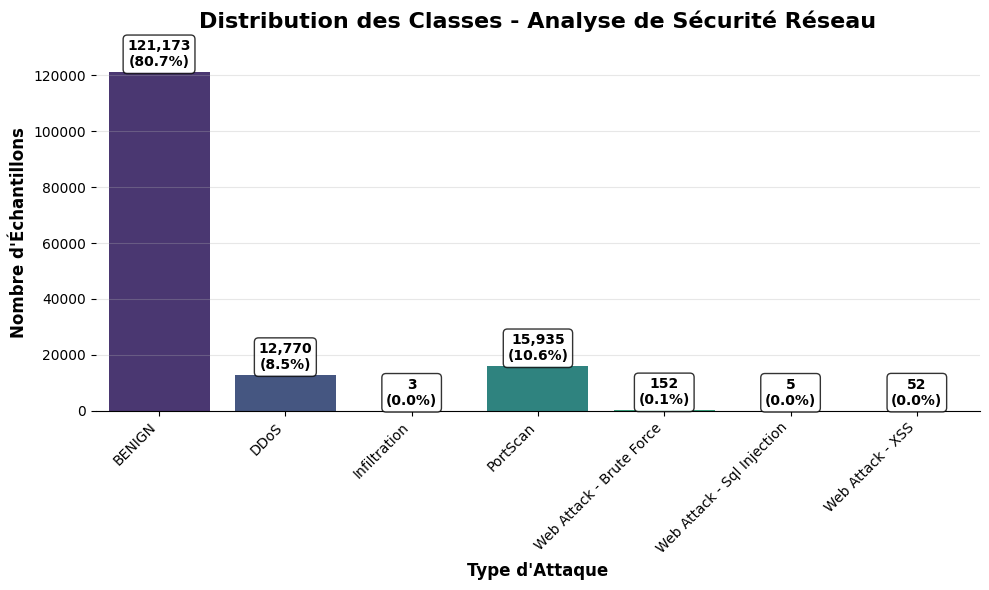

📊 DISTRIBUTION DÉTAILLÉE DES CLASSES:
🔸 BENIGN                    :  121,173 échantillons ( 80.73%)
🔸 DDoS                      :   12,770 échantillons (  8.51%)
🔸 Infiltration              :        3 échantillons (  0.00%)
🔸 PortScan                  :   15,935 échantillons ( 10.62%)
🔸 Web Attack - Brute Force  :      152 échantillons (  0.10%)
🔸 Web Attack - Sql Injection :        5 échantillons (  0.00%)
🔸 Web Attack - XSS          :       52 échantillons (  0.03%)


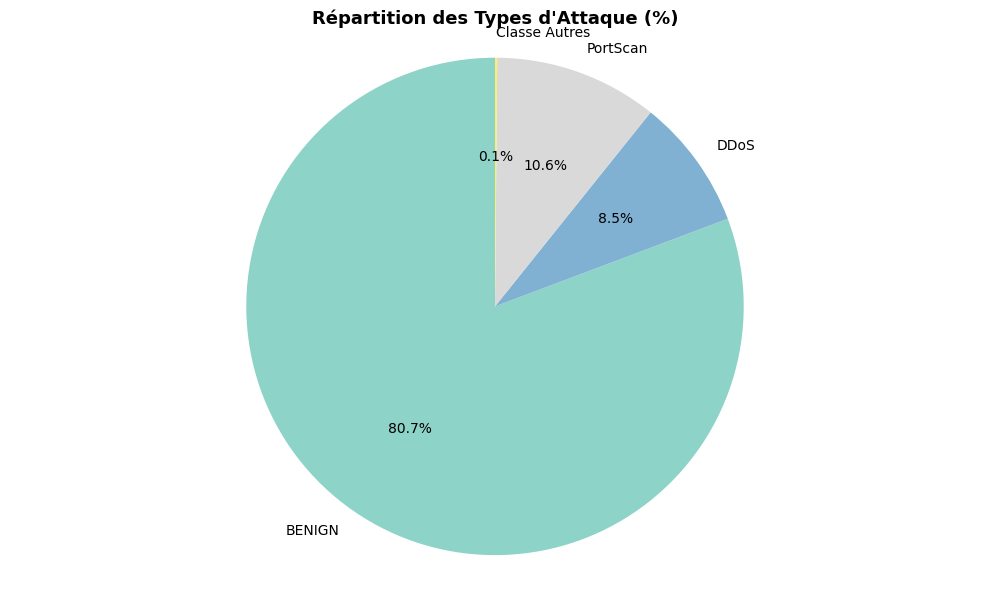


⚖️  ANALYSE DE L'ÉQUILIBRE DES CLASSES:
Classe la plus fréquente: BENIGN (121,173 échantillons)
Classe la moins fréquente: Infiltration (3 échantillons)
Ratio de déséquilibre: 40391.0x
⚠️  FORT DÉSÉQUILIBRE DÉTECTÉ - Considérer les techniques de rééchantillonnage


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Mapping des labels pour une meilleure lisibilité
label_mapping = {
    0: 'BENIGN',
    1: 'DDoS',
    2: 'Infiltration', 
    3: 'PortScan',
    4: 'Web Attack - Brute Force',
    5: 'Web Attack - Sql Injection',
    6: 'Web Attack - XSS'
}

# ==================== GRAPHIQUE AMÉLIORÉ ====================
plt.figure(figsize=(10, 6))

# Distribution des classes
class_distribution = sampled_df['Label_encoded'].value_counts().sort_index() # value_counts(): compte le nombre d’occurrences de chaque classe.

# Créer les noms de classes avec le mapping
class_names = [label_mapping.get(i, f'Classe {i}') for i in class_distribution.index]

# Créer le graphique avec seaborn pour un meilleur style
ax = sns.barplot(x=class_names, y=class_distribution.values, palette='viridis')

# Personnalisation avancée
plt.title('Distribution des Classes - Analyse de Sécurité Réseau', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Type d\'Attaque', fontsize=12, fontweight='bold')
plt.ylabel('Nombre d\'Échantillons', fontsize=12, fontweight='bold')

# Rotation des labels x pour meilleure lisibilité
plt.xticks(rotation=45, ha='right')

# Ajouter les valeurs sur les barres
for i, (name, value) in enumerate(zip(class_names, class_distribution.values)):
    percentage = (value / len(sampled_df)) * 100
    ax.text(i, value + 1000, f'{value:,}\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)) # ax.text : ajoute des valeurs numériques directement sur les barres du graphique

# Améliorer le style
sns.despine(left=True)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout() # ajuste la mise en page pour éviter que les textes se chevauchent.

plt.show()

# ==================== STATISTIQUES DÉTAILLÉES ====================
print("📊 DISTRIBUTION DÉTAILLÉE DES CLASSES:")
print("="*60)

total_samples = len(sampled_df)
for class_id, count in class_distribution.items():
    class_name = label_mapping.get(class_id, f'Classe {class_id}')
    percentage = (count / total_samples) * 100
    print(f"🔸 {class_name:<25} : {count:>8,} échantillons ({percentage:>6.2f}%)")

# ==================== GRAPHIQUE CAMEMBERT ====================
plt.figure(figsize=(10, 6))

# Filtrer les petites classes pour éviter la surcharge visuelle
threshold = 0.5  # Afficher séparément les classes > 0.5%
large_classes = class_distribution[class_distribution / total_samples * 100 > threshold]
small_classes = class_distribution[class_distribution / total_samples * 100 <= threshold]

if len(small_classes) > 0:
    # Regrouper les petites classes en "Autres"
    others_sum = small_classes.sum()
    large_classes['Autres'] = others_sum

# Créer les labels pour le camembert
pie_labels = [label_mapping.get(i, f'Classe {i}') for i in large_classes.index]
pie_sizes = large_classes.values
pie_colors = plt.cm.Set3(np.linspace(0, 1, len(pie_labels)))

# Camembert
plt.pie(pie_sizes, labels=pie_labels, colors=pie_colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 10})
plt.title('Répartition des Types d\'Attaque (%)', fontsize=13, fontweight='bold')
plt.axis('equal')  # Assurer un cercle parfait

plt.tight_layout()
plt.show()

# ==================== ANALYSE DE DÉSÉQUILIBRE ====================
print("\n⚖️  ANALYSE DE L'ÉQUILIBRE DES CLASSES:")
print("="*50)

max_count = class_distribution.max()
min_count = class_distribution.min()
imbalance_ratio = max_count / min_count

print(f"Classe la plus fréquente: {label_mapping[class_distribution.idxmax()]} ({max_count:,} échantillons)")
print(f"Classe la moins fréquente: {label_mapping[class_distribution.idxmin()]} ({min_count:,} échantillons)")
print(f"Ratio de déséquilibre: {imbalance_ratio:.1f}x")

if imbalance_ratio > 10:
    print("⚠️  FORT DÉSÉQUILIBRE DÉTECTÉ - Considérer les techniques de rééchantillonnage")
elif imbalance_ratio > 5:
    print("⚠️  Déséquilibre modéré détecté")
else:
    print("✅ Classes raisonnablement équilibrées")


- 2. ANALYSE DES CORRÉLATIONS GLOBALES

🎯 ANALYSE DE CORRÉLATION AVEC LA TARGET
📊 Features numériques analysées: 80

1. 📈 CALCUL DES CORRÉLATIONS...


C:\Users\sarah\AppData\Roaming\Python\Python312\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\sarah\AppData\Roaming\Python\Python312\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


🎯 CORRÉLATION AVEC LA TARGET (Top 20):
 1. PSH Flag Count                      : 0.4578
 2. Protocol                            : 0.3047
 3. Min Packet Length                   : 0.2744
 4. Bwd Packet Length Min               : 0.2248
 5. ACK Flag Count                      : 0.1607
 6. Bwd Packets/s                       : 0.1602
 7. Init_Win_bytes_forward              : 0.1539
 8. URG Flag Count                      : 0.1427
 9. Bwd IAT Total                       : 0.1293
10. Source Port                         : 0.1159
11. Avg Fwd Segment Size                : 0.1148
12. Fwd Packet Length Mean              : 0.1148
13. Fwd Packet Length Min               : 0.1080
14. Fwd Packet Length Max               : 0.1067
15. Bwd IAT Max                         : 0.1014
16. Flow Duration                       : 0.0999
17. Fwd IAT Total                       : 0.0967
18. Packet Length Variance              : 0.0957
19. Down/Up Ratio                       : 0.0938
20. Fwd PSH Flags             

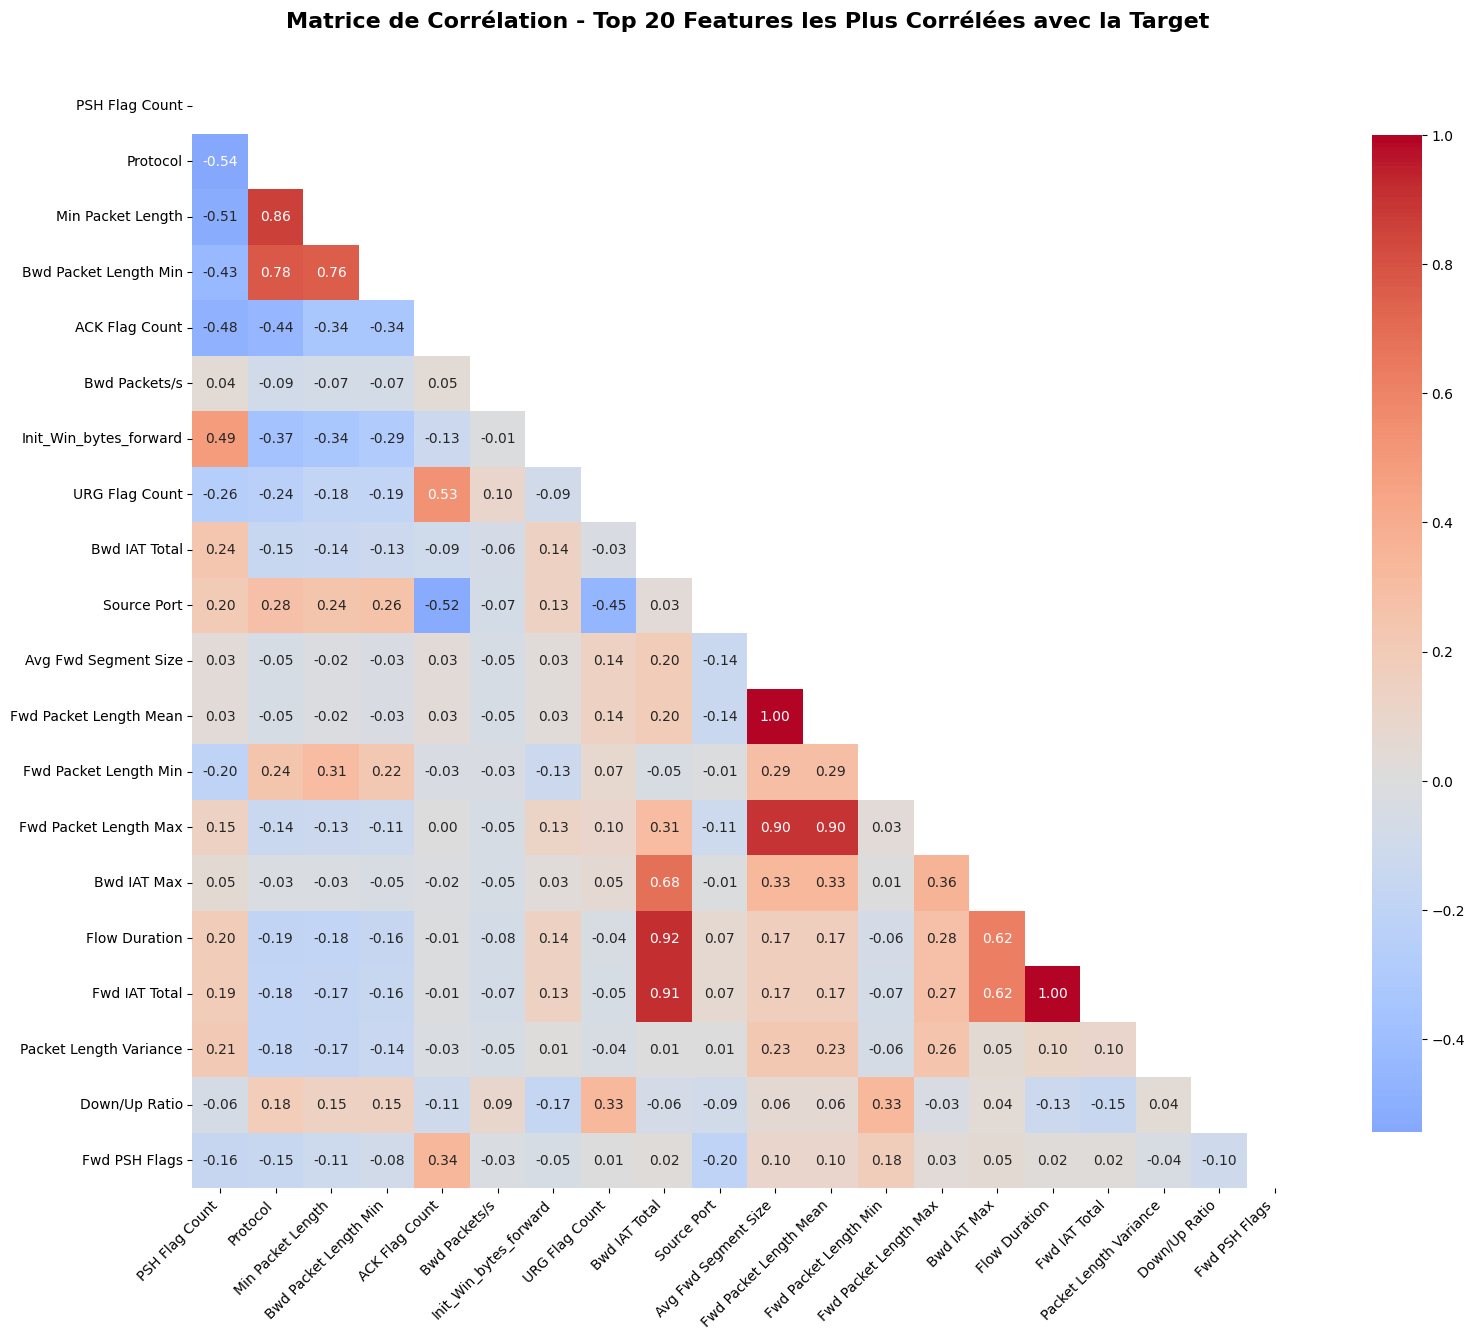


4. 📊 CRÉATION DU GRAPHIQUE DES CORRÉLATIONS...


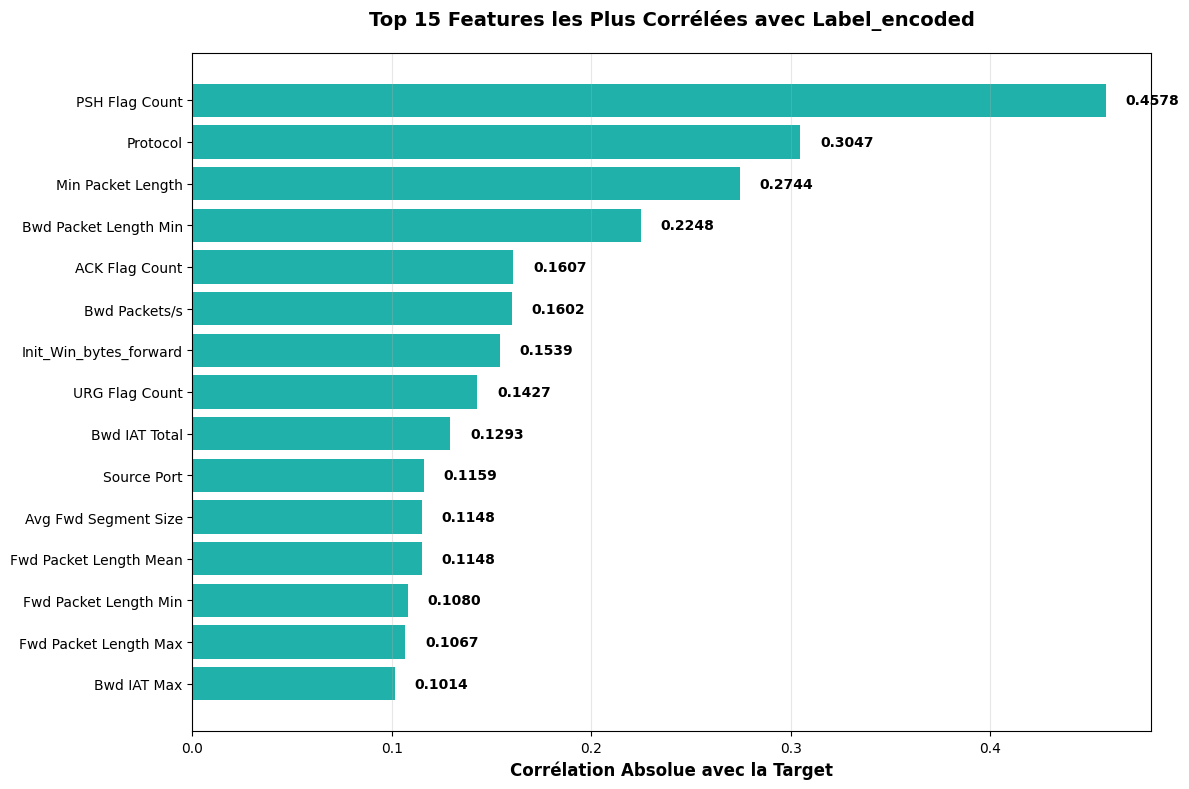


5. 🔄 DÉTECTION DES FEATURES REDONDANTES...
⚠️  6 paires de features très corrélées (> 0.9):
   • Bwd IAT Total (corr target: 0.1293)
     ↔ Flow Duration (corr target: 0.0999)
     📊 Corrélation mutuelle: 0.9178

   • Bwd IAT Total (corr target: 0.1293)
     ↔ Fwd IAT Total (corr target: 0.0967)
     📊 Corrélation mutuelle: 0.9148

   • Avg Fwd Segment Size (corr target: 0.1148)
     ↔ Fwd Packet Length Mean (corr target: 0.1148)
     📊 Corrélation mutuelle: 1.0000

   • Avg Fwd Segment Size (corr target: 0.1148)
     ↔ Fwd Packet Length Max (corr target: 0.1067)
     📊 Corrélation mutuelle: 0.9022

   • Fwd Packet Length Mean (corr target: 0.1148)
     ↔ Fwd Packet Length Max (corr target: 0.1067)
     📊 Corrélation mutuelle: 0.9022

   • Flow Duration (corr target: 0.0999)
     ↔ Fwd IAT Total (corr target: 0.0967)
     📊 Corrélation mutuelle: 0.9977

   ⚠️  Features redondantes détectées
   → Éliminer les doublons dans la sélection finale


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== CONFIGURATION ====================
print("🎯 ANALYSE DE CORRÉLATION AVEC LA TARGET")
print("="*50)

# Définir les colonnes à exclure
TARGET_COLUMNS = ['Label', 'AttackFlag', 'Label_encoded']
NON_FEATURE_COLUMNS = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']

# Préparer les données
y = sampled_df['Label_encoded']
X = sampled_df.drop(columns=TARGET_COLUMNS + NON_FEATURE_COLUMNS)

# Sélectionner seulement les features numériques
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"📊 Features numériques analysées: {len(numeric_features)}")

# ==================== CORRÉLATION AVEC LA TARGET ====================
print("\n1. 📈 CALCUL DES CORRÉLATIONS...")

# Calculer la corrélation avec la target
correlation_with_target = X[numeric_features].corrwith(y).abs().sort_values(ascending=False) #corrwith(y):Calcule la corrélation de chaque feature numérique avec la variable cible 

print("🎯 CORRÉLATION AVEC LA TARGET (Top 20):")
print("="*60)

for i, (feature, corr) in enumerate(correlation_with_target.head(20).items(), 1):
    print(f"{i:2d}. {feature:<35} : {corr:.4f}")

# ==================== HEATMAP DES TOP FEATURES ====================
print("\n2. 🔥 CRÉATION DE LA HEATMAP...")

# Prendre les top 20 features
top_corr_features = correlation_with_target.head(20).index

plt.figure(figsize=(16, 14))

# Créer la heatmap avec annotations
corr_matrix = X[top_corr_features].corr()# Génère la matrice de corrélation complète entre variables numériques (pour détecter la redondance)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Masquer le triangle supérieur
# np.triu(): Crée un masque triangulaire pour n’afficher que la moitié inférieure de la heatmap 
# pour rendre la heatmap plus lisible et éviter la répétition inutile des valeurs.

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True,
            cbar_kws={'shrink': 0.8})

plt.title('Matrice de Corrélation - Top 20 Features les Plus Corrélées avec la Target\n', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('correlation_heatmap_top_features.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== GRAPHIQUE DES TOP CORRÉLATIONS ====================
print("\n4. 📊 CRÉATION DU GRAPHIQUE DES CORRÉLATIONS...")

# Top 15 features pour le graphique
top_15_corr = correlation_with_target.head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_15_corr)), top_15_corr.values, color='lightseagreen') #plt.barh:Crée le graphique horizontal des top corrélations
plt.yticks(range(len(top_15_corr)), top_15_corr.index)
plt.xlabel('Corrélation Absolue avec la Target', fontsize=12, fontweight='bold')
plt.title('Top 15 Features les Plus Corrélées avec Label_encoded', 
          fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

# Ajouter les valeurs sur les bars
for bar, corr in zip(bars, top_15_corr.values):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{corr:.4f}', ha='left', va='center', fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('top_correlations_with_target.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== DÉTECTION DES DOUBLONS (FEATURES TRÈS CORRÉLÉES ENTRE ELLES) ====================
print("\n5. 🔄 DÉTECTION DES FEATURES REDONDANTES...")

# Analyser les corrélations entre les top features
top_features_corr_matrix = X[top_corr_features].corr().abs()

# Identifier les paires très corrélées (> 0.9)
high_corr_pairs = []
for i in range(len(top_features_corr_matrix.columns)):
    for j in range(i+1, len(top_features_corr_matrix.columns)):
        if top_features_corr_matrix.iloc[i, j] > 0.9:
            feature_i = top_features_corr_matrix.columns[i]
            feature_j = top_features_corr_matrix.columns[j]
            corr_value = top_features_corr_matrix.iloc[i, j]
            high_corr_pairs.append((feature_i, feature_j, corr_value))

if high_corr_pairs:
    print(f"⚠️  {len(high_corr_pairs)} paires de features très corrélées (> 0.9):")
    for feat1, feat2, corr in high_corr_pairs:
        corr1 = correlation_with_target[feat1]
        corr2 = correlation_with_target[feat2]
        print(f"   • {feat1} (corr target: {corr1:.4f})")
        print(f"     ↔ {feat2} (corr target: {corr2:.4f})")
        print(f"     📊 Corrélation mutuelle: {corr:.4f}\n")
else:
    print("✅ Aucune paire de features très corrélée détectée")


if high_corr_pairs:
    print("   ⚠️  Features redondantes détectées")
    print("   → Éliminer les doublons dans la sélection finale")

- 3. ANALYSE DE LA DISTRIBUTION DES FEATURES


🎯 ANALYSE DES 20 FEATURES LES PLUS CORRÉLÉES AVEC LA TARGET
✅ Features disponibles: 20/20

📈 CRÉATION DES HISTOGRAMMES POUR LES TOP FEATURES...


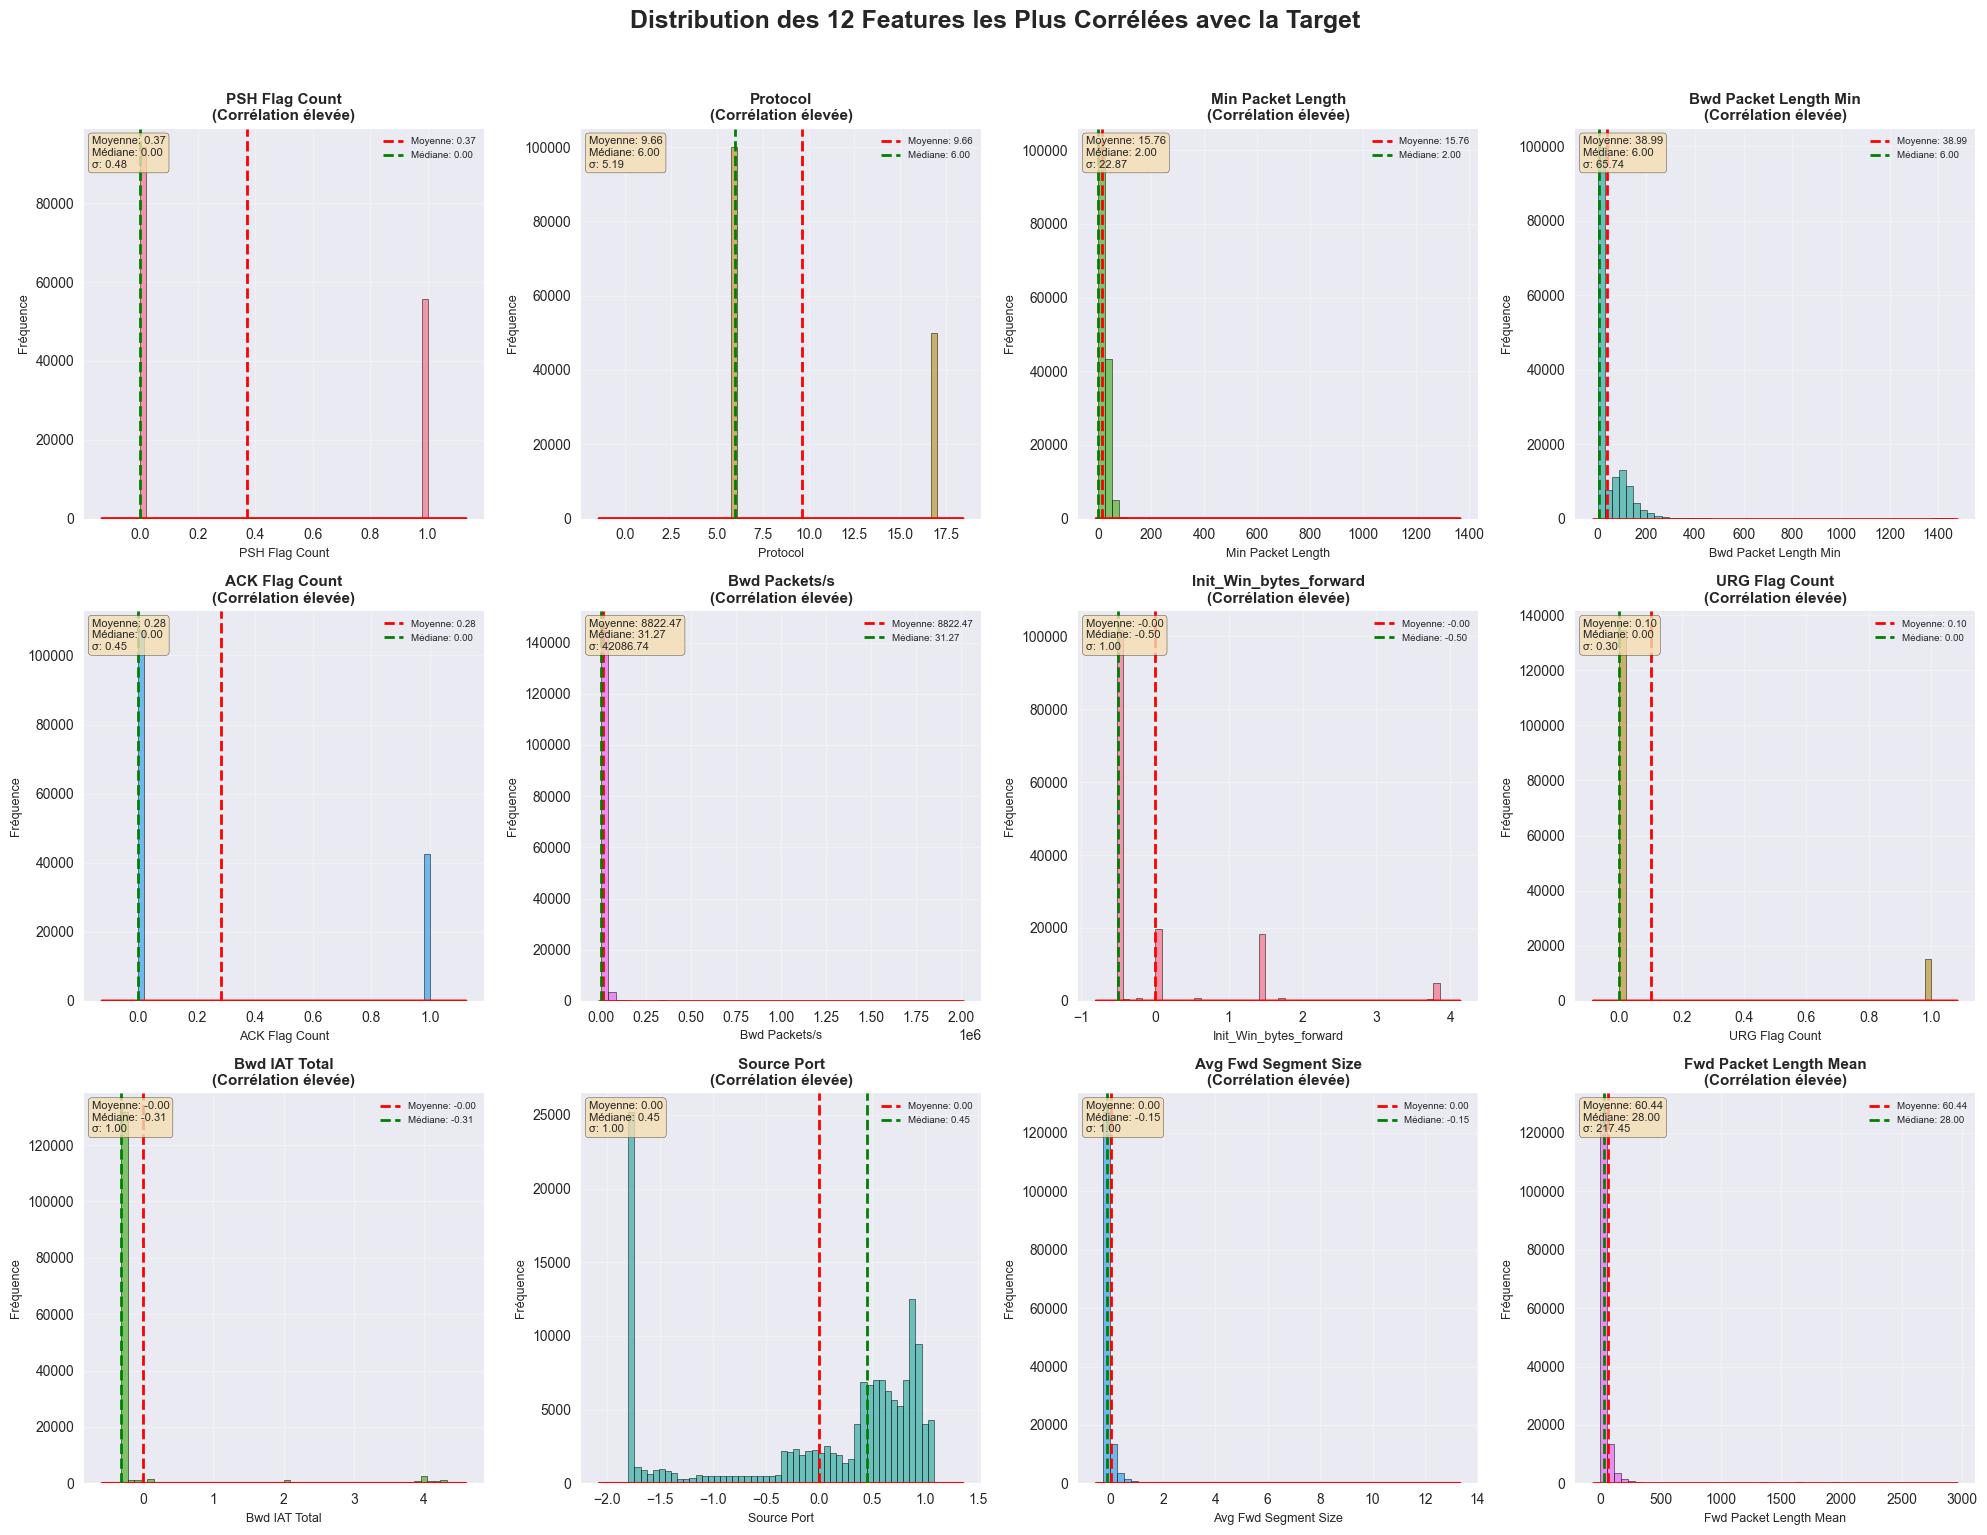


📦 CRÉATION DES BOXPLOTS POUR DÉTECTION DES OUTLIERS...


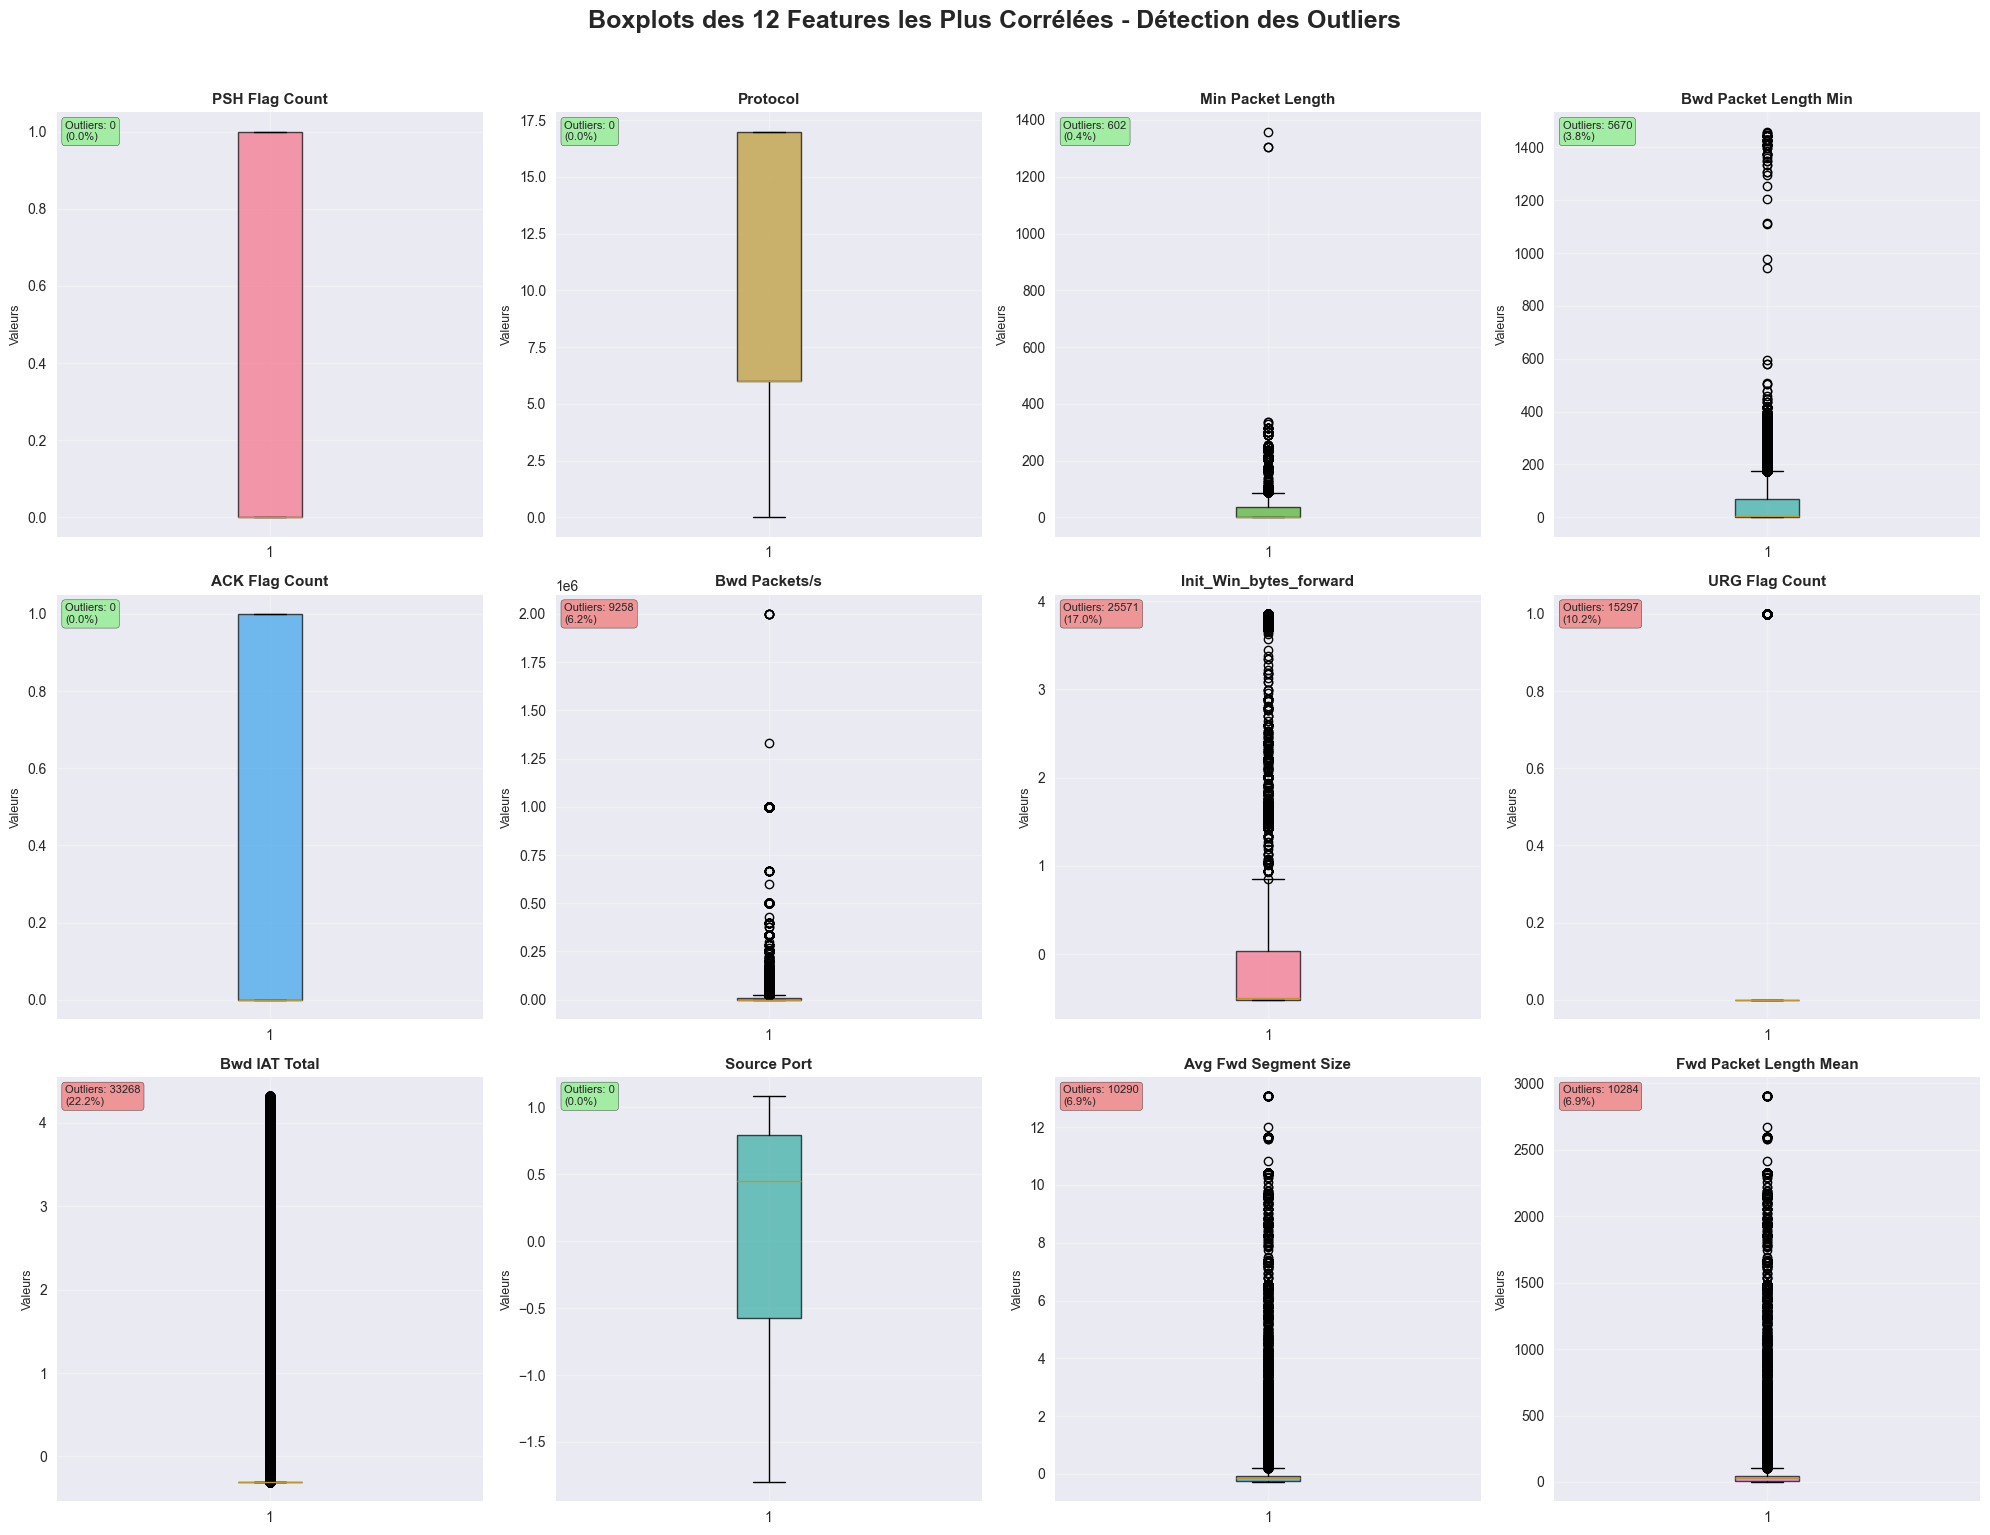


📊 ANALYSE STATISTIQUE DÉTAILLÉE DES TOP FEATURES:

📈 STATISTIQUES DESCRIPTIVES:
                   Feature   Moyenne  Médiane  Écart-type    Min          Max  Skewness  Valeurs uniques  Outliers  % Outliers
0           PSH Flag Count     0.372    0.000       0.483  0.000        1.000     0.530                2         0       0.000
1                 Protocol     9.663    6.000       5.189  0.000       17.000     0.705                3         0       0.000
2        Min Packet Length    15.763    2.000      22.873  0.000     1359.000     5.754              132       602       0.401
3    Bwd Packet Length Min    38.986    6.000      65.740  0.000     1460.000     4.506              362      5670       3.778
4           ACK Flag Count     0.284    0.000       0.451  0.000        1.000     0.960                2         0       0.000
5            Bwd Packets/s  8822.471   31.269   42086.741  0.000  2000000.000    19.410            71410      9258       6.168
6   Init_Win_bytes_forward    

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configuration pour de meilleurs graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ==================== DÉFINITION DES FEATURES BASÉE SUR L'ANALYSE ====================
# Les 20 features les plus corrélées avec la target selon votre analyse
top_correlated_features = [
    'PSH Flag Count',
    'Protocol', 
    'Min Packet Length',
    'Bwd Packet Length Min',
    'ACK Flag Count',
    'Bwd Packets/s',
    'Init_Win_bytes_forward',
    'URG Flag Count',
    'Bwd IAT Total',
    'Source Port',
    'Avg Fwd Segment Size',
    'Fwd Packet Length Mean',
    'Fwd Packet Length Min',
    'Fwd Packet Length Max',
    'Bwd IAT Max',
    'Flow Duration',
    'Fwd IAT Total',
    'Packet Length Variance',
    'Down/Up Ratio',
    'Fwd PSH Flags'
]

print("🎯 ANALYSE DES 20 FEATURES LES PLUS CORRÉLÉES AVEC LA TARGET")
print("="*70)

# Vérifier quelles features existent dans votre DataFrame
available_features = [f for f in top_correlated_features if f in sampled_df.columns]
missing_features = [f for f in top_correlated_features if f not in sampled_df.columns]

print(f"✅ Features disponibles: {len(available_features)}/{len(top_correlated_features)}")
if missing_features:
    print(f"❌ Features manquantes: {missing_features}")

# Prendre les 12 premières features disponibles pour la visualisation (2x6 grid)
features_to_plot = available_features[:12]

# ==================== GRAPHIQUE PRINCIPAL - DISTRIBUTIONS DES TOP FEATURES ====================
print("\n📈 CRÉATION DES HISTOGRAMMES POUR LES TOP FEATURES...")

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Distribution des 12 Features les Plus Corrélées avec la Target', 
             fontsize=18, fontweight='bold', y=1.02)

for i, feature in enumerate(features_to_plot):
    row, col = i // 4, i % 4
    
    # Créer l'histogramme
    n, bins, patches = axes[row, col].hist(sampled_df[feature], bins=50, alpha=0.7, 
                                          color=f'C{i}', edgecolor='black', linewidth=0.5)
    
    # Ajouter une ligne de densité
    try:
        sns.kdeplot(sampled_df[feature], ax=axes[row, col], color='red', linewidth=2)
    except:
        pass
    
    # Statistiques descriptives
    mean_val = sampled_df[feature].mean()
    std_val = sampled_df[feature].std()
    median_val = sampled_df[feature].median()
    
    # Ajouter les lignes statistiques
    axes[row, col].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                          label=f'Moyenne: {mean_val:.2f}')
    axes[row, col].axvline(median_val, color='green', linestyle='--', linewidth=2, 
                          label=f'Médiane: {median_val:.2f}')
    
    # Personnalisation
    axes[row, col].set_title(f'{feature}\n(Corrélation élevée)', fontsize=11, fontweight='bold')
    axes[row, col].set_xlabel(feature, fontsize=9)
    axes[row, col].set_ylabel('Fréquence', fontsize=9)
    axes[row, col].legend(fontsize=7)
    axes[row, col].grid(True, alpha=0.3)
    
    # Ajouter une boîte avec les statistiques
    stats_text = f'Moyenne: {mean_val:.2f}\nMédiane: {median_val:.2f}\nσ: {std_val:.2f}'
    axes[row, col].text(0.02, 0.98, stats_text, transform=axes[row, col].transAxes,
                       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                       fontsize=8)

plt.tight_layout()
plt.show()

# ==================== GRAPHIQUE SUPPLÉMENTAIRE - BOXPLOTS ====================
print("\n📦 CRÉATION DES BOXPLOTS POUR DÉTECTION DES OUTLIERS...")

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Boxplots des 12 Features les Plus Corrélées - Détection des Outliers', 
             fontsize=18, fontweight='bold', y=1.02)

for i, feature in enumerate(features_to_plot):
    row, col = i // 4, i % 4
    
    # Créer le boxplot
    boxplot = axes[row, col].boxplot(sampled_df[feature], patch_artist=True)
    
    # Personnalisation des couleurs
    boxplot['boxes'][0].set_facecolor(f'C{i}')
    boxplot['boxes'][0].set_alpha(0.7)
    
    # Calcul des outliers
    Q1 = sampled_df[feature].quantile(0.25)
    Q3 = sampled_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = sampled_df[(sampled_df[feature] < lower_bound) | (sampled_df[feature] > upper_bound)][feature]
    
    # Personnalisation
    axes[row, col].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[row, col].set_ylabel('Valeurs', fontsize=9)
    axes[row, col].grid(True, alpha=0.3)
    
    # Ajouter le nombre d'outliers
    outlier_percentage = (len(outliers) / len(sampled_df)) * 100
    axes[row, col].text(0.02, 0.98, f'Outliers: {len(outliers)}\n({outlier_percentage:.1f}%)', 
                       transform=axes[row, col].transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', 
                               facecolor='lightcoral' if outlier_percentage > 5 else 'lightgreen', 
                               alpha=0.8),
                       fontsize=8)

plt.tight_layout()
plt.show()

# ==================== ANALYSE STATISTIQUE DÉTAILLÉE ====================
print("\n📊 ANALYSE STATISTIQUE DÉTAILLÉE DES TOP FEATURES:")
print("="*70)

# Créer un DataFrame pour les statistiques
stats_data = []

for feature in features_to_plot:
    stats = {
        'Feature': feature,
        'Moyenne': sampled_df[feature].mean(),
        'Médiane': sampled_df[feature].median(),
        'Écart-type': sampled_df[feature].std(),
        'Min': sampled_df[feature].min(),
        'Max': sampled_df[feature].max(),
        'Skewness': sampled_df[feature].skew(),
        'Valeurs uniques': sampled_df[feature].nunique()
    }
    
    # Calcul des outliers
    Q1 = sampled_df[feature].quantile(0.25) # quantile() : calcule les bornes pour détecter les outliers via l’IQR.
    Q3 = sampled_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers_count = len(sampled_df[(sampled_df[feature] < (Q1 - 1.5 * IQR)) | (sampled_df[feature] > (Q3 + 1.5 * IQR))])
    stats['Outliers'] = outliers_count
    stats['% Outliers'] = (outliers_count / len(sampled_df)) * 100
    
    stats_data.append(stats)

# Créer et afficher le DataFrame des statistiques
stats_df = pd.DataFrame(stats_data)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n📈 STATISTIQUES DESCRIPTIVES:")
print(stats_df.round(3))

# ==================== ANALYSE DE LA NORMALITÉ ET SKEWNESS ====================
print("\n🔍 ANALYSE DE LA DISTRIBUTION (SKEWNESS):")
print("="*50)

for feature in features_to_plot: # applique toutes les analyses sur les variables sélectionnées.
    skewness = sampled_df[feature].skew() # skew() : mesure l’asymétrie de la distribution.
    if abs(skewness) > 1:
        dist_type = "FORTEMENT ASYMÉTRIQUE"
        recommendation = "→ Transformation log/sqrt recommandée"
        color = "🔴"
    elif abs(skewness) > 0.5:
        dist_type = "Modérément asymétrique"
        recommendation = "→ Transformation possible"
        color = "🟡"
    else:
        dist_type = "Approximativement symétrique"
        recommendation = "→ Distribution normale"
        color = "🟢"
    
    print(f"{color} {feature:<25}: {dist_type:<30} (skewness: {skewness:7.3f})")
    if abs(skewness) > 0.5:
        print(f"   {recommendation}")

💡 STRATÉGIE DE FEATURE SELECTION:
   + Conserver les features avec haute corrélation avec la target
   + Éliminer les doublons (features fortement corrélées entre elles)
   + Appliquer une transformation aux features asymétriques
   + Considérer le traitement des outliers pour les features importantes

-----

# CLASSIFICATION BINAIRE : ATTAQUE vs NON-ATTAQUE

-----

* ÉTAPE 1 : PRÉPARATION DES DONNÉES BINAIRES 

In [37]:
print("🎯 CONFIGURATION POUR LA CLASSIFICATION BINAIRE...")

# A. UTILISER DIRECTEMENT LA COLONNE AttackFlag POUR LA TARGET BINAIRE
df_binaire = sampled_df.copy()

# Vérification de la distribution
print("📊 DISTRIBUTION BINAIRE (AttackFlag):")
attack_distribution = df_binaire['AttackFlag'].value_counts()
print(attack_distribution)

for flag, count in attack_distribution.items():
    label = "ATTACK" if flag == 1 else "BENIGN"
    percentage = (count / len(df_binaire)) * 100
    print(f"   • {label}: {count} échantillons ({percentage:.2f}%)")

# B. TARGET BINAIRE
y_binary = df_binaire['AttackFlag']


🎯 CONFIGURATION POUR LA CLASSIFICATION BINAIRE...
📊 DISTRIBUTION BINAIRE (AttackFlag):
AttackFlag
0    121173
1     28917
Name: count, dtype: int64
   • BENIGN: 121173 échantillons (80.73%)
   • ATTACK: 28917 échantillons (19.27%)


* ÉTAPE 2 : PRÉTRAITEMENT SPÉCIFIQUE BINAIRE

In [54]:
print("\n🔧 PRÉTRAITEMENT POUR CLASSIFICATION BINAIRE...")

# Appliquer les mêmes transformations
X_binary_processed = apply_feature_transformations_final(X_binary, features_finales)

# Scaling robuste
X_binary_final, binary_scaler = apply_robust_scaling(X_binary_processed, features_robust)

print(f"✅ Préprocessing binaire terminé!")
print(f"   • Shape: {X_binary_final.shape}")
print(f"   • Target: {y_binary.unique()}")


🔧 PRÉTRAITEMENT POUR CLASSIFICATION BINAIRE...
🔄 Application des transformations (sans bruit)...
   ✅ Bwd Packets/s:
      - Skewness avant: 19.41
      - Skewness après: 0.40
      - Amélioration: 97.9%
   ✅ Bwd IAT Total:
      - Skewness avant: 3.37
      - Skewness après: 3.04
      - Amélioration: 9.8%
   ✅ Features binaires conservées sans transformation:
      - PSH Flag Count: 2 valeurs uniques
      - ACK Flag Count: 2 valeurs uniques
      - URG Flag Count: 2 valeurs uniques
      - Protocol: 3 valeurs uniques
✅ Scaling robuste appliqué à 7 features
✅ Préprocessing binaire terminé!
   • Shape: (150090, 20)
   • Target: [0 1]


* ÉTAPE 4 : RÉÉCHANTILLONNAGE BINAIRE OPTIMISÉ

In [ ]:
print("\n🔄 RÉÉCHANTILLONNAGE POUR CLASSIFICATION BINAIRE...")

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline # imblearn : Fournit des outils pour le rééchantillonnage (comme SMOTE).

# Stratégie optimisée pour binaire
binary_over_strategy = {1: 40000}  # Sur-échantillonner les attaques
binary_under_strategy = {0: 60000} # Sous-échantillonner le trafic normal

binary_resampling_pipeline = Pipeline([
    ('oversample', SMOTE(sampling_strategy=binary_over_strategy, random_state=42)),
    ('undersample', RandomUnderSampler(sampling_strategy=binary_under_strategy, random_state=42))
])

# Appliquer le rééchantillonnage
X_binary_resampled, y_binary_resampled = binary_resampling_pipeline.fit_resample(X_binary_final, y_binary)

print(f"📊 Distribution APRÈS rééchantillonnage binaire:")
binary_resampled_dist = pd.Series(y_binary_resampled).value_counts()
for flag, count in binary_resampled_dist.items():
    label = "ATTACK" if flag == 1 else "BENIGN"
    print(f"   • {label}: {count} échantillons")



🔄 RÉÉCHANTILLONNAGE POUR CLASSIFICATION BINAIRE...
📊 Distribution APRÈS rééchantillonnage binaire:
   • BENIGN: 60000 échantillons
   • ATTACK: 40000 échantillons


* ÉTAPE 5 : Application des MODÈLES  CLASSIFICATION BINAIRE

In [ ]:
print("\n🤖 CONFIGURATION DES MODÈLES BINAIRES...")

from sklearn.ensemble import RandomForestClassifier # sklearn.ensemble : RandomForestClassifier et XGBClassifier : Utilisés pour entraîner des modèles d'ensemble
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Modèles optimisés pour classification binaire
binary_models = {
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        # scale_pos_weight=benign_count/attack_count,  # Important pour le déséquilibre
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        class_weight='balanced',  # Gestion automatique du déséquilibre
        random_state=42,
        n_jobs=-1
    ),
    'LogisticRegression': LogisticRegression(
        C=1.0,
        class_weight='balanced',
        random_state=42,
        max_iter=1000,
        n_jobs=-1
    )
}

# Fonction d'évaluation pour classification binaire
def evaluate_binary_model(model, X, y, model_name):
    """
    Évaluation complète pour classification binaire
    """
    print(f"\n📊 ÉVALUATION BINAIRE - {model_name}")
    print("="*50)
    
    # Split des données
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    # Entraînement
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Métriques
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"🎯 MÉTRIQUES PRINCIPALES:")
    print(f"   • Accuracy:  {accuracy:.4f}")
    print(f"   • Precision: {precision:.4f}")
    print(f"   • Recall:    {recall:.4f}")
    print(f"   • F1-Score:  {f1:.4f}")
    
    # Rapport de classification
    print(f"\n📋 RAPPORT DE CLASSIFICATION:")
    print(classification_report(y_test, y_pred, target_names=['BENIGN', 'ATTACK']))
    
    # Matrice de confusion
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['BENIGN', 'ATTACK'], 
                yticklabels=['BENIGN', 'ATTACK'])
    plt.title(f'Matrice de Confusion - {model_name}\n(Classification Binaire)', 
              fontsize=14, fontweight='bold')
    plt.ylabel('Vraie étiquette', fontweight='bold')
    plt.xlabel('Étiquette prédite', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return model, f1, accuracy, precision, recall



🤖 CONFIGURATION DES MODÈLES BINAIRES...


* ÉTAPE 6 : ENTRAÎNEMENT ET ÉVALUATION BINAIRE 

🚀 LANCEMENT DE L'ENTRAÎNEMENT BINAIRE...

📊 ÉVALUATION BINAIRE - XGBoost
🎯 MÉTRIQUES PRINCIPALES:
   • Accuracy:  0.9965
   • Precision: 0.9959
   • Recall:    0.9954
   • F1-Score:  0.9956

📋 RAPPORT DE CLASSIFICATION:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     12000
      ATTACK       1.00      1.00      1.00      8000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



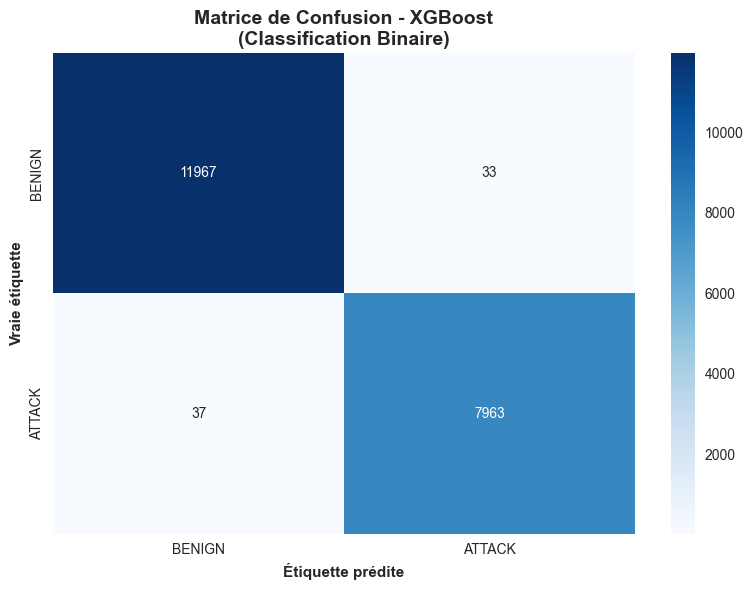

✅ XGBoost - Binaire terminé avec succès!

📊 ÉVALUATION BINAIRE - RandomForest
🎯 MÉTRIQUES PRINCIPALES:
   • Accuracy:  0.9968
   • Precision: 0.9950
   • Recall:    0.9969
   • F1-Score:  0.9959

📋 RAPPORT DE CLASSIFICATION:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     12000
      ATTACK       1.00      1.00      1.00      8000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



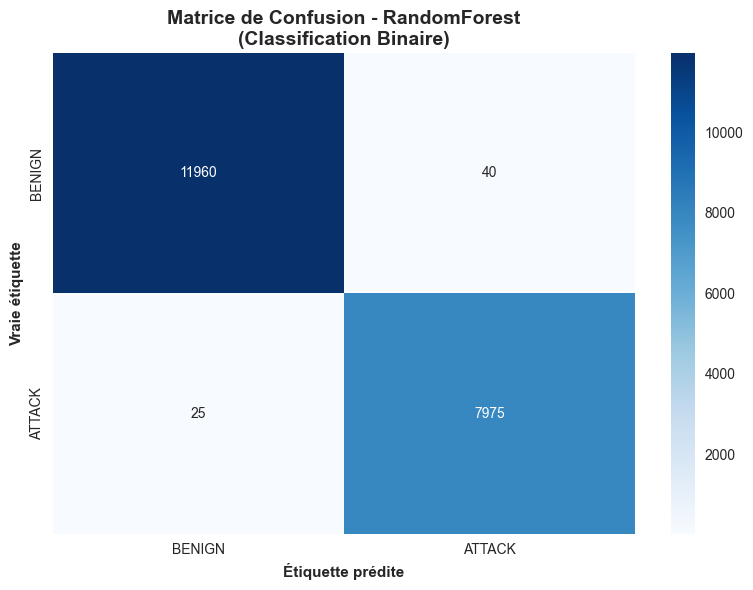

✅ RandomForest - Binaire terminé avec succès!

📊 ÉVALUATION BINAIRE - LogisticRegression
🎯 MÉTRIQUES PRINCIPALES:
   • Accuracy:  0.8993
   • Precision: 0.8422
   • Recall:    0.9210
   • F1-Score:  0.8798

📋 RAPPORT DE CLASSIFICATION:
              precision    recall  f1-score   support

      BENIGN       0.94      0.88      0.91     12000
      ATTACK       0.84      0.92      0.88      8000

    accuracy                           0.90     20000
   macro avg       0.89      0.90      0.90     20000
weighted avg       0.90      0.90      0.90     20000



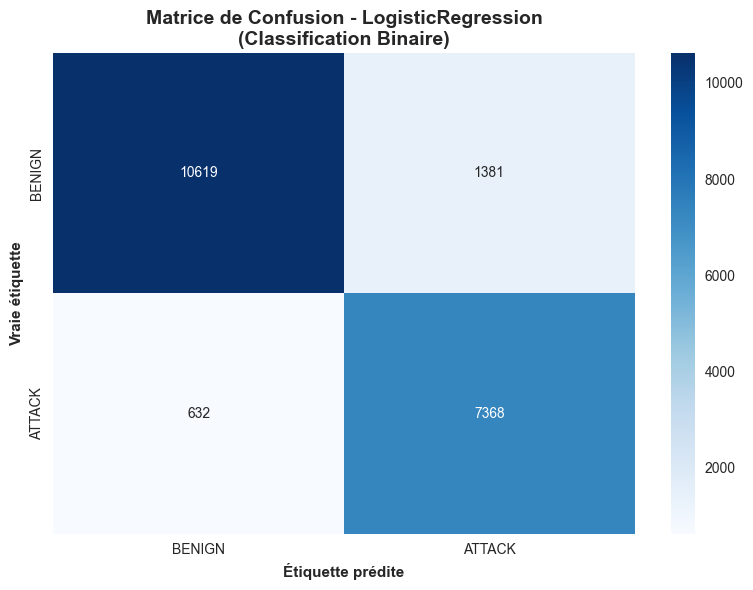

✅ LogisticRegression - Binaire terminé avec succès!


In [ ]:
print("🚀 LANCEMENT DE L'ENTRAÎNEMENT BINAIRE...")

binary_results = {}
best_binary_model = None
best_binary_f1 = 0

for name, model in binary_models.items():
    try:
        trained_model, f1, accuracy, precision, recall = evaluate_binary_model(
            model, X_binary_resampled, y_binary_resampled, name
        )
        
        binary_results[name] = {
            'model': trained_model,
            'f1': f1,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall
        }
        
        if f1 > best_binary_f1:
            best_binary_f1 = f1
            best_binary_model = trained_model
            best_binary_model_name = name
            
        print(f"✅ {name} - Binaire terminé avec succès!")
        
    except Exception as e:
        print(f"❌ Erreur avec {name} (binaire): {e}")


* ÉTAPE 7 : ANALYSE DES RÉSULTATS BINAIRES


🎉 RÉSULTATS FINAUX - CLASSIFICATION BINAIRE
🏆 MEILLEUR MODÈLE BINAIRE: RandomForest
⭐ MEILLEUR F1-SCORE: 0.9945

📊 COMPARAISON DES MODÈLES BINAIRES:
Modèle           | F1-Score | Accuracy | Precision | Recall
-------------------------------------------------------
XGBoost         | 0.9941   | 0.9952  | 0.9891   | 0.9991
RandomForest    | 0.9945   | 0.9956  | 0.9923   | 0.9968
LogisticRegression | 0.9050   | 0.9181  | 0.8436   | 0.9761

🎯 TOP 10 FEATURES (Classification Binaire - RandomForest):
   13. Fwd Packet Length Max     : 0.2130
    7. Init_Win_bytes_forward    : 0.1730
   11. Avg Fwd Segment Size      : 0.1679
   10. Source Port               : 0.0913
   12. Flow Duration             : 0.0710
    6. Bwd Packets/s             : 0.0549
    9. Bwd IAT Total             : 0.0465
    3. Min Packet Length         : 0.0366
    2. Protocol                  : 0.0353
    4. Bwd Packet Length Min     : 0.0349


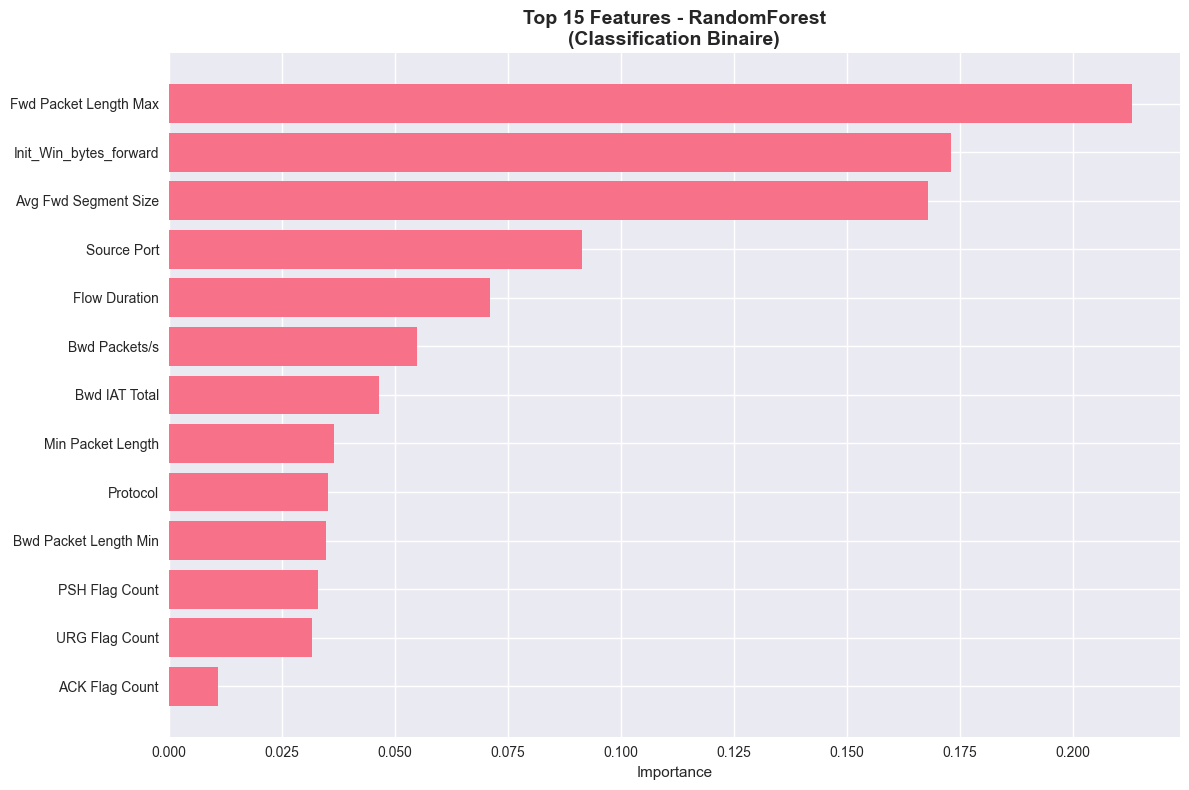

In [ ]:
print("\n" + "="*70)
print("🎉 RÉSULTATS FINAUX - CLASSIFICATION BINAIRE")
print("="*70)

if best_binary_model is not None:
    print(f"🏆 MEILLEUR MODÈLE BINAIRE: {best_binary_model_name}")
    print(f"⭐ MEILLEUR F1-SCORE: {best_binary_f1:.4f}")
    
    # Comparaison détaillée
    print(f"\n📊 COMPARAISON DES MODÈLES BINAIRES:")
    print("Modèle           | F1-Score | Accuracy | Precision | Recall")
    print("-" * 55)
    for name, result in binary_results.items():
        print(f"{name:<15} | {result['f1']:.4f}   | {result['accuracy']:.4f}  | {result['precision']:.4f}   | {result['recall']:.4f}")
    
    # Importance des features pour le meilleur modèle
    if hasattr(best_binary_model, 'feature_importances_'): # vérifie si le modèle fournit une importance des variables.
        print(f"\n🎯 TOP 10 FEATURES (Classification Binaire - {best_binary_model_name}):")
        binary_feature_importance = pd.DataFrame({
            'feature': features_finales,
            'importance': best_binary_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        for i, row in binary_feature_importance.head(10).iterrows():
            print(f"   {i+1:2d}. {row['feature']:<25} : {row['importance']:.4f}")
        
        # Visualisation
        plt.figure(figsize=(12, 8))
        top_binary_features = binary_feature_importance.head(15)
        plt.barh(top_binary_features['feature'], top_binary_features['importance'])
        plt.xlabel('Importance')
        plt.title(f'Top 15 Features - {best_binary_model_name}\n(Classification Binaire)', 
                  fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()


----

-------

# CLASSIFICATION MULTI-CLASSES

--------

* ÉTAPE 1: PRÉPARATION DES DONNÉES CRITIQUE


In [ ]:
# A. GESTION DU DÉSÉQUILIBRE DES CLASSES 
# On garde tout les informations qui peuvent être informatifs => Maintient la diversité des patterns d'attaque et Réduit les pertes d'information

# Supprimer UNIQUEMENT Infiltration 
classes_a_supprimer = ['Infiltration']
df_filtre = sampled_df[~sampled_df['Label'].isin(classes_a_supprimer)].copy() # isin():Permet de filtrer les lignes qui correspondent à certaines valeurs dans une colonne 

# Regrouper TOUTES les attaques Web ensemble
df_filtre['Label'] = df_filtre['Label'].replace({
    'Web Attack - Brute Force': 'Web_Attack',
    'Web Attack - Sql Injection': 'Web_Attack', 
    'Web Attack - XSS': 'Web_Attack'
})

print("📊 DISTRIBUTION APRÈS REGROUPEMENT OPTIMISÉ:")
print(df_filtre['Label'].value_counts())
print(f"Pourcentages:")
for label, count in df_filtre['Label'].value_counts().items():
    percentage = (count / len(df_filtre)) * 100
    print(f"  • {label}: {count} ({percentage:.2f}%)")

📊 DISTRIBUTION APRÈS REGROUPEMENT OPTIMISÉ:
Label
BENIGN        121173
PortScan       15935
DDoS           12770
Web_Attack       209
Name: count, dtype: int64
Pourcentages:
  • BENIGN: 121173 (80.74%)
  • PortScan: 15935 (10.62%)
  • DDoS: 12770 (8.51%)
  • Web_Attack: 209 (0.14%)


In [ ]:
# B. RÉÉCHANTILLONNAGE STRATÉGIQUE 
# imblearn: Une bibliothèque utilisée pour les techniques de rééchantillonnage dans les cas de déséquilibre de classes. 
# Elle fournit des outils pour gérer les classes suréchantillonnées ou sous-échantillonnées.
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Pipeline : Permet de créer une chaîne d'étapes d'apprentissage machine. => il est utilisé pour appliquer SMOTE puis RandomUnderSampler de manière ordonnée.

over_strategy = {
    'DDoS': 15000,      
    'PortScan': 18000,     
    'Web_Attack': 3000  
}

under_strategy = {'BENIGN': 60000}  

# Pipeline de rééchantillonnage
resampling_pipeline = Pipeline([
    ('oversample', SMOTE(sampling_strategy=over_strategy, random_state=42)), # SMOTE: Utilisé pour l'over-sampling pour les classes minoritaires en interpolant entre les échantillons existants.
    ('undersample', RandomUnderSampler(sampling_strategy=under_strategy, random_state=42))
])    # RandomUnderSampler : Utilisé pour l'under-sampling. Cela consiste à réduire la taille de la classe majoritaire pour équilibrer les classes
      # under_strategy : Définit la taille cible pour la classe majoritaire
print("🎯 STRATÉGIE DE RÉÉCHANTILLONNAGE OPTIMISÉE:")
print(f"  • Web_Attack: 209 → 3,000 (x{3000/209:.1f})")
print(f"  • DDoS: 12,770 → 15,000 (x{15000/12770:.1f})")
print(f"  • PortScan: 15,935 → 18,000 (x{18000/15935:.1f})")
print(f"  • BENIGN: 121,173 → 60,000 (x{60000/121173:.1f})")

🎯 STRATÉGIE DE RÉÉCHANTILLONNAGE OPTIMISÉE:
  • Web_Attack: 209 → 3,000 (x14.4)
  • DDoS: 12,770 → 15,000 (x1.2)
  • PortScan: 15,935 → 18,000 (x1.1)
  • BENIGN: 121,173 → 60,000 (x0.5)


* ÉTAPE 2: FEATURE SELECTION OPTIMISÉE


In [48]:
print("🎯 FEATURE SELECTION INTELLIGENTE ")

# A. ÉLIMINATION DES DOUBLONS BASÉE SUR L'ANALYSE DE CORRÉLATION
# Règles : Garder la feature avec la plus haute corrélation avec la target

features_a_supprimer = [
    'Fwd Packet Length Mean',      # ❌ Doublon parfait de Avg Fwd Segment Size (corrélation identique 0.1148)
    'Fwd IAT Total',               # ❌ Redondant avec Bwd IAT Total (corrélation inférieure: 0.0967 vs 0.1293)
    # 'Flow Duration' est gardé car corrélation 0.0999 vs Bwd IAT Total 0.1293 → différents
]

# B. TOP FEATURES BASÉES SUR L'ANALYSE (triées par corrélation avec target)
top_features = [
    'PSH Flag Count',              # 🏆 Meilleure corrélation (0.4578)
    'Protocol',                    # 🥈 Haute corrélation (0.3047)
    'Min Packet Length',           # 🥉 Forte corrélation (0.2744)
    'Bwd Packet Length Min',       # Importante (0.2248)
    'ACK Flag Count',              # Importante (0.1607)
    'Bwd Packets/s',               # Bonne corrélation (0.1602)
    'Init_Win_bytes_forward',      # Bonne corrélation (0.1539)
    'URG Flag Count',              # Bonne corrélation (0.1427)
    'Bwd IAT Total',               # Bonne corrélation (0.1293) → GARDÉ
    'Source Port',                 # Bonne corrélation (0.1159)
    'Avg Fwd Segment Size',        # Bonne corrélation (0.1148) → GARDÉ
    'Flow Duration',               # Bonne corrélation (0.0999) → GARDÉ
    'Fwd Packet Length Max'        # Bonne corrélation (0.1067)
]

# Features finales après nettoyage
features_finales = [f for f in top_features if f not in features_a_supprimer]
print(f"✅ Features sélectionnées: {len(features_finales)}")
print(f"📋 Liste finale: {features_finales}")

🎯 FEATURE SELECTION INTELLIGENTE 
✅ Features sélectionnées: 13
📋 Liste finale: ['PSH Flag Count', 'Protocol', 'Min Packet Length', 'Bwd Packet Length Min', 'ACK Flag Count', 'Bwd Packets/s', 'Init_Win_bytes_forward', 'URG Flag Count', 'Bwd IAT Total', 'Source Port', 'Avg Fwd Segment Size', 'Flow Duration', 'Fwd Packet Length Max']


* ÉTAPE 3: PRÉ-TRAITEMENT DES FEATURES


In [ ]:
from sklearn.preprocessing import RobustScaler

print("🔧 PRÉ-TRAITEMENT des features")

# A. TRANSFORMATIONS SPÉCIFIQUES PAR TYPE DE FEATURE
features_log = ['Bwd Packets/s', 'Bwd IAT Total']

# Features binaires/discrètes - LAISSER INTACTES
features_binaires = ['PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Protocol']

# Features pour scaling robuste
features_robust = [
    'Init_Win_bytes_forward', 'Avg Fwd Segment Size', 'Fwd Packet Length Max',
    'Min Packet Length', 'Bwd Packet Length Min', 'Source Port', 'Flow Duration'
]

def apply_feature_transformations_final(df, features): # Applique une transformation logarithmique (log1p) aux features très asymétriques (pour réduire la skewness).
    """
    Version finale sans ajout de bruit
    """
    df_transformed = df.copy()
    
    print("🔄 Application des transformations (sans bruit)...")
    
    # Seulement la transformation log pour les features très asymétriques
    for feature in features_log:
        if feature in df_transformed.columns:
            # Gestion des valeurs négatives
            if (df_transformed[feature] < 0).any():
                min_val = df_transformed[feature].min()
                if min_val < 0:
                    df_transformed[feature] = df_transformed[feature] - min_val + 1e-6
            
            # Application log1p
            original_skew = df_transformed[feature].skew()
            df_transformed[feature] = np.log1p(df_transformed[feature]) # on applique log(1 + x) pour lisser les valeurs extrêmes
            new_skew = df_transformed[feature].skew() # Réévaluation de la skewness
            
            print(f"   ✅ {feature}:")
            print(f"      - Skewness avant: {original_skew:.2f}")
            print(f"      - Skewness après: {new_skew:.2f}")
            print(f"      - Amélioration: {((original_skew - abs(new_skew)) / original_skew * 100):.1f}%")
    
    # Les features binaires restent intactes - PAS DE BRUIT
    print(f"   ✅ Features binaires conservées sans transformation:")
    for feature in features_binaires:
        if feature in df_transformed.columns:
            unique_vals = df_transformed[feature].nunique()
            print(f"      - {feature}: {unique_vals} valeurs uniques")
    
    return df_transformed

# C. FONCTION POUR APPLIQUER LE SCALING ROBUSTE
def apply_robust_scaling(df, features):# Applique un scaling robuste (basé sur la médiane et l’IQR) aux colonnes continues.
    """
    Applique le scaling robuste aux features spécifiées
    """
    df_scaled = df.copy()
    scaler = RobustScaler() # RobustScaler: → Normalisation robuste des données (insensible aux valeurs extrêmes / outliers)
    
    # Appliquer le scaling
    df_scaled[features] = scaler.fit_transform(df_scaled[features])
    
    print(f"✅ Scaling robuste appliqué à {len(features)} features")
    return df_scaled, scaler

# D. PIPELINE COMPLÈTE DE PRÉTRAITEMENT
def full_preprocessing_pipeline(df, target_column='Label_encoded'):
    """
    Pipeline complet de prétraitement
    """
    print("🚀 LANCEMENT DU PRÉTRAITEMENT COMPLET")
    print("="*50)
    
    # 1. Séparation features/target
    X = df[features_finales].copy()
    y = df[target_column].copy()
    
    print(f"📊 Données initiales: {X.shape}")
    
    # 2. Application des transformations logarithmiques
    X_transformed = apply_feature_transformations_final(X, features_finales)
    
    # 3. Application du scaling robuste
    X_final, robust_scaler = apply_robust_scaling(X_transformed, features_robust)
    
    print(f"   • Shape finale: {X_final.shape}")
    
    return X_final, y, robust_scaler

# APPLICATION DU PRÉTRAITEMENT SUR df_filtre
print("\n" + "="*60)
print("🎯 APPLICATION DU PRÉTRAITEMENT SUR LES DONNÉES FILTRÉES")
print("="*60)

# Appliquer le prétraitement complet
X_processed, y_processed, scaler = full_preprocessing_pipeline(df_filtre)

🔧 PRÉ-TRAITEMENT des features

🎯 APPLICATION DU PRÉTRAITEMENT SUR LES DONNÉES FILTRÉES
🚀 LANCEMENT DU PRÉTRAITEMENT COMPLET
📊 Données initiales: (150087, 13)
🔄 Application des transformations (sans bruit)...
   ✅ Bwd Packets/s:
      - Skewness avant: 19.41
      - Skewness après: 0.40
      - Amélioration: 97.9%
   ✅ Bwd IAT Total:
      - Skewness avant: 3.37
      - Skewness après: 3.04
      - Amélioration: 9.8%
   ✅ Features binaires conservées sans transformation:
      - PSH Flag Count: 2 valeurs uniques
      - ACK Flag Count: 2 valeurs uniques
      - URG Flag Count: 2 valeurs uniques
      - Protocol: 3 valeurs uniques
✅ Scaling robuste appliqué à 7 features
   • Shape finale: (150087, 13)


* ÉTAPE 4: PIPELINE COMPLÈTE DE MODÉLISATION

In [ ]:
print("🔄 CORRECTION DU RÉÉCHANTILLONNAGE SMOTE...")

# Vérification de la distribution actuelle
print("📊 DISTRIBUTION ACTUELLE DES CLASSES:")
label_distribution = df_filtre['Label'].value_counts()
print(label_distribution)

# Vérifier si Web_Attack a assez d'échantillons pour SMOTE (au moins 6)
web_attack_count = label_distribution.get('Web_Attack', 0)
print(f"🔍 Web_Attack samples: {web_attack_count}")

if web_attack_count < 6:
    print("⚠️  Web_Attack n'a pas assez d'échantillons pour SMOTE standard")
    print("🔄 Adaptation de la stratégie de rééchantillonnage...")
    
    # OPTION 1 : SMOTE avec k_means_estimator pour petites classes
    from imblearn.over_sampling import SMOTE
    from sklearn.cluster import KMeans # KMeans : Pour effectuer un clustering (utilisé ici avec SMOTE pour de petites classes).
    
    # Utiliser SMOTE avec un k plus petit pour les petites classes
    smote_adapted = SMOTE(
        random_state=42,
        k_neighbors=min(5, web_attack_count - 1) if web_attack_count > 1 else 1
    )
    
    # Rééchantillonnage adapté
    X_resampled, y_resampled = smote_adapted.fit_resample(X_processed, df_filtre['Label'])
    
else:
    # Utiliser le pipeline de rééchantillonnage original
    X_resampled, y_resampled = resampling_pipeline.fit_resample(X_processed, df_filtre['Label']) # fit_resample() (imblearn) :Applique le rééchantillonnage (SMOTE)

# Encoder les labels textuels en numérique pour l'entraînement
from sklearn.preprocessing import LabelEncoder # LabelEncoder: Pour encoder des labels textuels en valeurs numériques avant l'entraînement.

label_encoder = LabelEncoder()
y_resampled_encoded = label_encoder.fit_transform(y_resampled) # Encode les étiquettes catégorielles (texte) en valeurs numériques,

print(f"✅ RÉÉCHANTILLONNAGE RÉUSSI!")
print(f"📊 Distribution APRÈS rééchantillonnage:")
resampled_dist = pd.Series(y_resampled).value_counts()
for label, count in resampled_dist.items():
    print(f"   • {label}: {count} échantillons")

print(f"🎯 Encodage des labels: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")


🔄 CORRECTION DU RÉÉCHANTILLONNAGE SMOTE...
📊 DISTRIBUTION ACTUELLE DES CLASSES:
Label
BENIGN        121173
PortScan       15935
DDoS           12770
Web_Attack       209
Name: count, dtype: int64
🔍 Web_Attack samples: 209
✅ RÉÉCHANTILLONNAGE RÉUSSI!
📊 Distribution APRÈS rééchantillonnage:
   • BENIGN: 60000 échantillons
   • PortScan: 18000 échantillons
   • DDoS: 15000 échantillons
   • Web_Attack: 3000 échantillons
🎯 Encodage des labels: {'BENIGN': 0, 'DDoS': 1, 'PortScan': 2, 'Web_Attack': 3}


* ÉTAPE 5: Application des modéles de classification 


🤖 ENTRAÎNEMENT DES MODÈLES...
🚀 LANCEMENT DE L'ENTRAÎNEMENT...

📊 ÉVALUATION DE RandomForest
🎯 F1-Score (macro) - Validation Croisée (5 folds):
   • Moyenne: 0.9856
   • Std: 0.0023
   • Scores: ['0.9829', '0.9840', '0.9858', '0.9856', '0.9897']

📈 MÉTRIQUES DÉTAILLÉES:
   • F1-Score (macro): 0.9861
   • F1-Score (weighted): 0.9955

📋 RAPPORT DE CLASSIFICATION:
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      1.00     12000
        DDoS       0.99      1.00      1.00      3000
    PortScan       1.00      1.00      1.00      3600
  Web_Attack       0.92      0.99      0.95       600

    accuracy                           1.00     19200
   macro avg       0.98      1.00      0.99     19200
weighted avg       1.00      1.00      1.00     19200



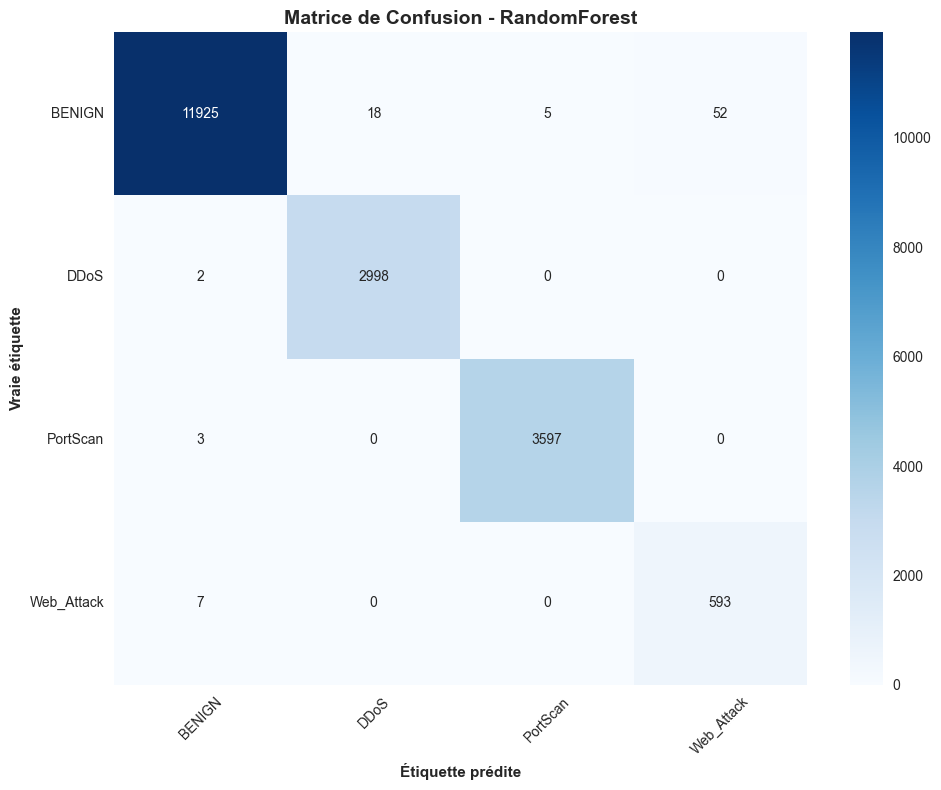

✅ RandomForest terminé avec succès!

📊 ÉVALUATION DE XGBoost
🎯 F1-Score (macro) - Validation Croisée (5 folds):
   • Moyenne: 0.9873
   • Std: 0.0014
   • Scores: ['0.9864', '0.9863', '0.9879', '0.9862', '0.9898']

📈 MÉTRIQUES DÉTAILLÉES:
   • F1-Score (macro): 0.9879
   • F1-Score (weighted): 0.9963

📋 RAPPORT DE CLASSIFICATION:
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      1.00     12000
        DDoS       1.00      1.00      1.00      3000
    PortScan       1.00      1.00      1.00      3600
  Web_Attack       0.93      0.99      0.96       600

    accuracy                           1.00     19200
   macro avg       0.98      1.00      0.99     19200
weighted avg       1.00      1.00      1.00     19200



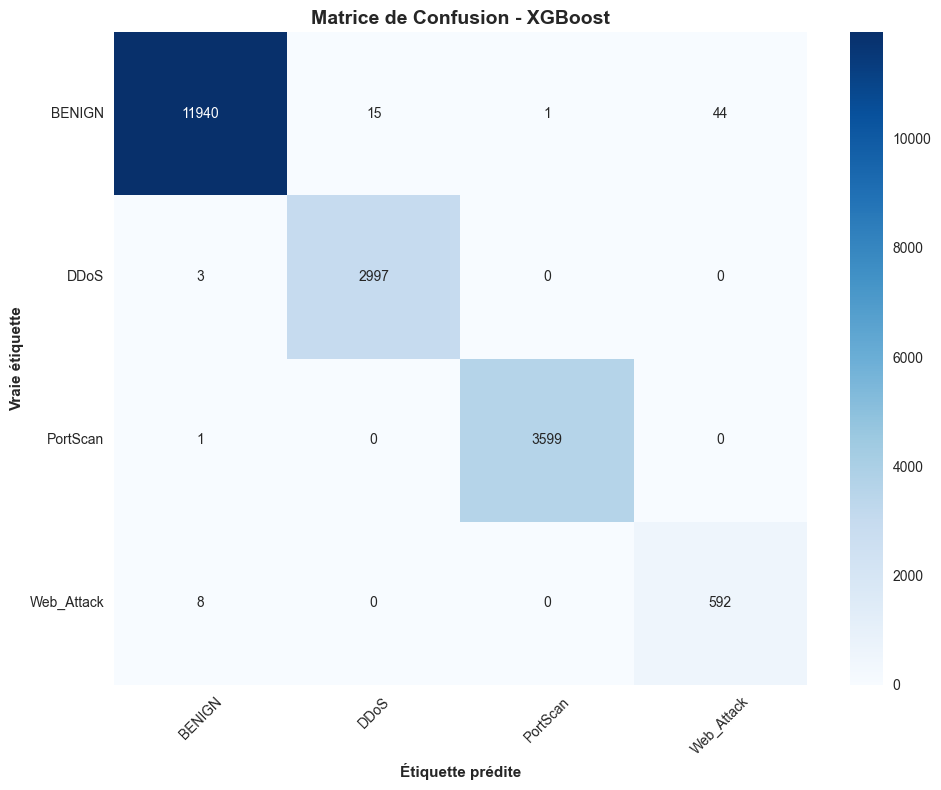

✅ XGBoost terminé avec succès!


In [ ]:
print("\n🤖 ENTRAÎNEMENT DES MODÈLES...")

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Définition des modèles optimisés
models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=150,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=150,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
}

# Fonction d'évaluation améliorée
def evaluate_model_improved(model, X, y, model_name, label_encoder):
    """
    Évaluation complète d'un modèle avec métriques détaillées
    """
    print(f"\n📊 ÉVALUATION DE {model_name}")
    print("="*60)
    
    # Validation croisée
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1_macro', n_jobs=-1)
    print(f"🎯 F1-Score (macro) - Validation Croisée (5 folds):")
    print(f"   • Moyenne: {cv_scores.mean():.4f}")
    print(f"   • Std: {cv_scores.std():.4f}")
    print(f"   • Scores: {[f'{s:.4f}' for s in cv_scores]}")
    
    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    # Entraînement et prédiction
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Métriques détaillées
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n📈 MÉTRIQUES DÉTAILLÉES:")
    print(f"   • F1-Score (macro): {f1_macro:.4f}")
    print(f"   • F1-Score (weighted): {f1_weighted:.4f}")
    
    # Rapport de classification
    print(f"\n📋 RAPPORT DE CLASSIFICATION:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    # Matrice de confusion
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_encoder.classes_, 
                yticklabels=label_encoder.classes_)
    plt.title(f'Matrice de Confusion - {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('Vraie étiquette', fontweight='bold')
    plt.xlabel('Étiquette prédite', fontweight='bold')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return model, cv_scores.mean(), f1_macro

# Entraînement et évaluation des modèles
best_model = None
best_model_name = None
best_score = 0
results = {}

print("🚀 LANCEMENT DE L'ENTRAÎNEMENT...")

for name, model in models.items():
    try:
        trained_model, cv_score, f1_score_val = evaluate_model_improved( # evaluate_model_improved : Validation croisée (5 folds) pour évaluer la performance du modèle avec le F1-score macro.
            model, X_resampled, y_resampled_encoded, name, label_encoder
        )
        
        results[name] = {
            'model': trained_model,
            'cv_score': cv_score,
            'f1_score': f1_score_val
        }
        
        if cv_score > best_score:
            best_score = cv_score
            best_model = trained_model
            best_model_name = name
            
        print(f"✅ {name} terminé avec succès!")
        
    except Exception as e:
        print(f"❌ Erreur avec {name}: {e}")

* ÉTAPE 6: ANALYSE DES RÉSULTATS ET INTERPRÉTATION



🎉 RÉSULTATS FINAUX DE LA MODÉLISATION
🏆 MEILLEUR MODÈLE: XGBoost
⭐ SCORE F1 (macro): 0.9872

📊 COMPARAISON DES MODÈLES:
   • RandomForest: F1-CV = 0.9851, F1-Test = 0.9856
   • XGBoost     : F1-CV = 0.9872, F1-Test = 0.9880

🎯 IMPORTANCE DES FEATURES (XGBoost):
    4. Bwd Packet Length Min     : 0.2865
   13. Fwd Packet Length Max     : 0.2732
    1. PSH Flag Count            : 0.1309
   11. Avg Fwd Segment Size      : 0.0880
    9. Bwd IAT Total             : 0.0569
    6. Bwd Packets/s             : 0.0434
    8. URG Flag Count            : 0.0402
    7. Init_Win_bytes_forward    : 0.0269
   12. Flow Duration             : 0.0245
   10. Source Port               : 0.0147
    3. Min Packet Length         : 0.0072
    5. ACK Flag Count            : 0.0063
    2. Protocol                  : 0.0013


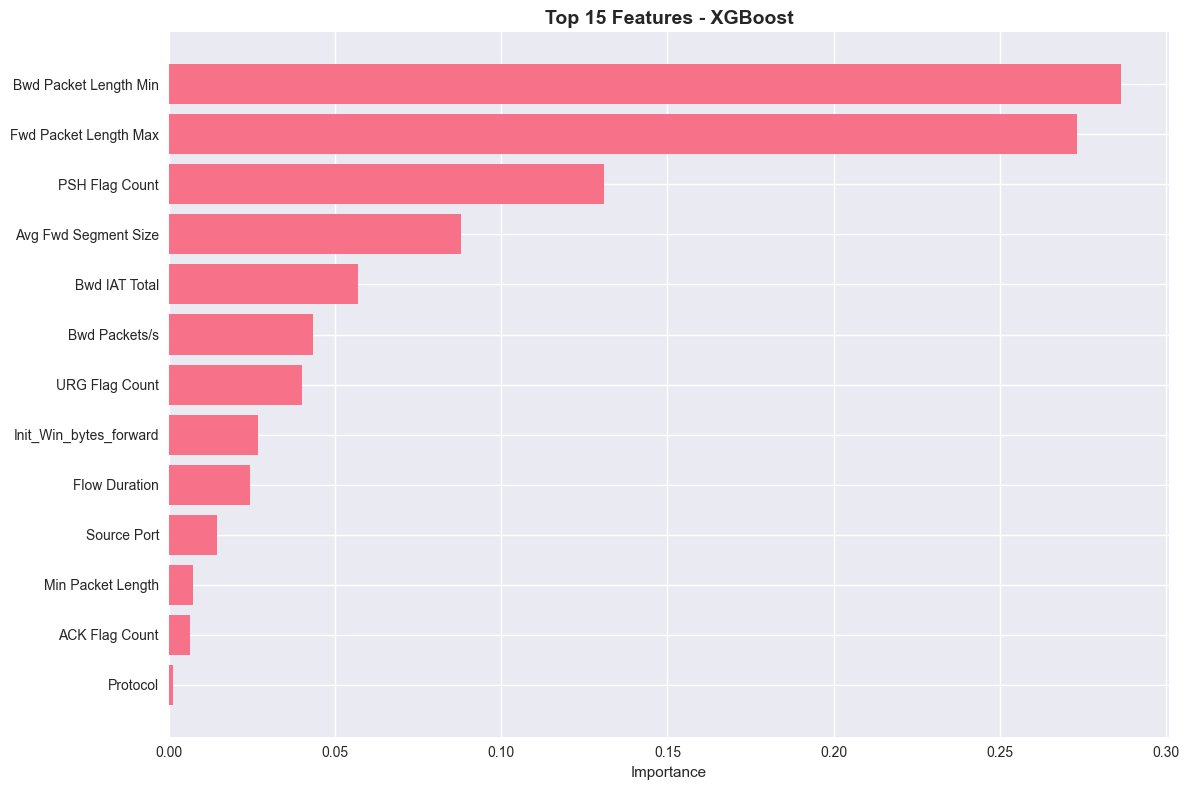

In [124]:
print("\n" + "="*70)
print("🎉 RÉSULTATS FINAUX DE LA MODÉLISATION")
print("="*70)

if best_model is not None:
    print(f"🏆 MEILLEUR MODÈLE: {best_model_name}")
    print(f"⭐ SCORE F1 (macro): {best_score:.4f}")
    
    # Comparaison des modèles
    print(f"\n📊 COMPARAISON DES MODÈLES:")
    for name, result in results.items():
        print(f"   • {name:<12}: F1-CV = {result['cv_score']:.4f}, F1-Test = {result['f1_score']:.4f}")
    
    # Importance des features (si Random Forest ou XGBoost)
    if hasattr(best_model, 'feature_importances_'):
        print(f"\n🎯 IMPORTANCE DES FEATURES ({best_model_name}):")
        feature_importance = pd.DataFrame({
            'feature': features_finales,
            'importance': best_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        for i, row in feature_importance.iterrows():
            print(f"   {i+1:2d}. {row['feature']:<25} : {row['importance']:.4f}")
        
        # Visualisation de l'importance des features
        plt.figure(figsize=(12, 8))
        top_features = feature_importance.head(15)
        plt.barh(top_features['feature'], top_features['importance'])
        plt.xlabel('Importance')
        plt.title(f'Top 15 Features - {best_model_name}', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    
else:
    print("❌ Aucun modèle n'a pu être entraîné avec succès")

F1 score : 
+ Adapté aux classes déséquilibrées : Ce score est plus fiable lorsque les données sont déséquilibrées.

+ Pertinent pour des contextes où les faux négatifs sont coûteux : Comme dans la détection d'intrusions, où manquer une attaque peut avoir de lourdes conséquences.

--------

------